In [1]:
!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("vishala28/swat-dataset-secure-water-treatment-system")
print(f"Dataset downloaded to: {path}")


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset downloaded to: C:\Users\Dax\.cache\kagglehub\datasets\vishala28\swat-dataset-secure-water-treatment-system\versions\3


In [2]:
# Install SHAP if missing in the Colab environment
!pip install "shap<0.50" matplotlib networkx scikit-learn tensorflow "numpy<2" pyarrow --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import shap
import warnings
import gc
import os

warnings.filterwarnings('ignore')

# Deep Learning & ML
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

# Optimize memory and set plotting styles
tf.keras.backend.clear_session()
plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use('dark_background')
COLORS = {'normal': '#2ecc71', 'attack': '#e74c3c', 'layer1': '#3498db', 'layer2': '#f1c40f', 'layer3': '#9b59b6'}

print(f"TensorFlow Version: {tf.__version__}")
# Check if Colab GPU is active
if len(tf.config.list_physical_devices('GPU')) > 0:
    print("✅ GPU is active and ready.")
else:
    print("⚠️ WARNING: GPU not found. Go to Runtime > Change runtime type and select T4 GPU.")


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



TensorFlow Version: 2.21.0
⚠️ WARNING: GPU not found. Go to Runtime > Change runtime type and select T4 GPU.


In [3]:
# ==========================================
# ⚙️ USER CONFIGURATION: DATASET UPLOAD
# ==========================================
# Option 1: If your files are in the Colab filesystem (uploaded via the folder icon on the left)
PATH_NORMAL = r'C:\Users\Dax\.cache\kagglehub\datasets\vishala28\swat-dataset-secure-water-treatment-system\versions\3\normal.csv'
PATH_ATTACK = r'C:\Users\Dax\.cache\kagglehub\datasets\vishala28\swat-dataset-secure-water-treatment-system\versions\3\attack.csv'

# --- OR ---
# Option 2: If mounting Google Drive (Uncomment the two lines below)
# from google.colab import drive
# drive.mount('/content/drive')
# PATH_NORMAL = '/content/drive/MyDrive/your_path/normal_data.csv'

print("Loading original dataset...")
try:
    df_normal = pd.read_csv(PATH_NORMAL)
    df_attack = pd.read_csv(PATH_ATTACK)

    df_normal['Attack_Label'] = 0
    df_attack['Attack_Label'] = 1

    # Colab RAM limitation safeguard: Sample data if it exceeds 200,000 rows
    MAX_ROWS = 200000
    if len(df_normal) > MAX_ROWS:
        print(f"Downsampling normal data from {len(df_normal)} to {MAX_ROWS} to prevent Colab RAM crash...")
        df_normal = df_normal.sample(MAX_ROWS, random_state=42).reset_index(drop=True)

    df = pd.concat([df_normal, df_attack], ignore_index=True)

    # --- NEW CLEANING STEP TO PREVENT 'NaN' LOSS ---
    print("Cleaning dirty data (handling missing/infinite values)...")
    df = df.replace([np.inf, -np.inf], np.nan) # Convert infinities to NaN
    df = df.ffill().fillna(0) # Forward fill missing data, then replace any leftovers with 0

    print(f"✅ Data loaded and cleaned successfully. Total shape: {df.shape}")

except FileNotFoundError:
    print(f"❌ ERROR: Could not find the CSV files. Please upload them to Colab.")
    raise

# ==========================================
# ⚙️ USER CONFIGURATION: FEATURE SELECTION
# ==========================================
# List the exact column names from your CSV that represent physical sensors.
# The AI Defender will monitor these.
SENSOR_COLUMNS = [
    'FIT101',  # Flow Indicator Transmitter (Inlet flow)
    'LIT101',  # Level Indicator Transmitter (Tank level)
    'MV101',   # Motorized Valve (Controls water inflow)
    'P101',    # Raw Water Pump 1
    'P102'     # Raw Water Pump 2 (Backup)
]

# Ensure the specified columns actually exist in your dataframe
missing_cols = [col for col in SENSOR_COLUMNS if col not in df.columns]
if missing_cols:
    print(f"⚠️ Warning: These columns were not found in your CSV: {missing_cols}")
    # Fallback: Auto-select numeric columns if user config fails
    print("Auto-selecting all numeric columns for modeling...")
    SENSOR_COLUMNS = df.select_dtypes(include=[np.number]).columns.drop('Attack_Label').tolist()

print(f"Features selected for AI monitoring: {len(SENSOR_COLUMNS)} sensors.")

Loading original dataset...
Downsampling normal data from 1387098 to 200000 to prevent Colab RAM crash...
Cleaning dirty data (handling missing/infinite values)...
✅ Data loaded and cleaned successfully. Total shape: (254621, 54)
⚠️ Warning: These columns were not found in your CSV: ['MV101']
Auto-selecting all numeric columns for modeling...
Features selected for AI monitoring: 51 sensors.


In [4]:
print("Preprocessing and creating time-series sequences...")

# Scale Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[SENSOR_COLUMNS].values).astype(np.float32)

# Sequence Generator
SEQ_LENGTH = 5
def create_sequences(data, seq_length):
    n = len(data) - seq_length + 1
    seqs = np.zeros((n, seq_length, data.shape[1]), dtype=np.float32)
    for i in range(n): seqs[i] = data[i:i+seq_length]
    return seqs

X_seq = create_sequences(X_scaled, SEQ_LENGTH)
y_labels = df['Attack_Label'].values[SEQ_LENGTH-1:]

# Split logic: Train purely on normal data, test on mixed data
normal_indices = np.where(y_labels == 0)[0]
attack_indices = np.where(y_labels == 1)[0]

# Take 80% of normal data for training
train_size = int(len(normal_indices) * 0.8)
train_idx = normal_indices[:train_size]

# The rest (20% normal + ALL attacks) goes to testing
test_idx = np.concatenate([normal_indices[train_size:], attack_indices])
np.random.shuffle(test_idx) # Shuffle test set

X_train_seq = X_seq[train_idx]
X_test_seq = X_seq[test_idx]
y_test = y_labels[test_idx]

print(f"✅ Training sequences (Normal Only): {X_train_seq.shape}")
print(f"✅ Testing sequences (Mixed): {X_test_seq.shape}")

# Free RAM
del df, X_scaled, X_seq
gc.collect()

Preprocessing and creating time-series sequences...
✅ Training sequences (Normal Only): (159996, 5, 51)
✅ Testing sequences (Mixed): (94621, 5, 51)


9

Constructing Custom SWaT CPS Threat Graph...


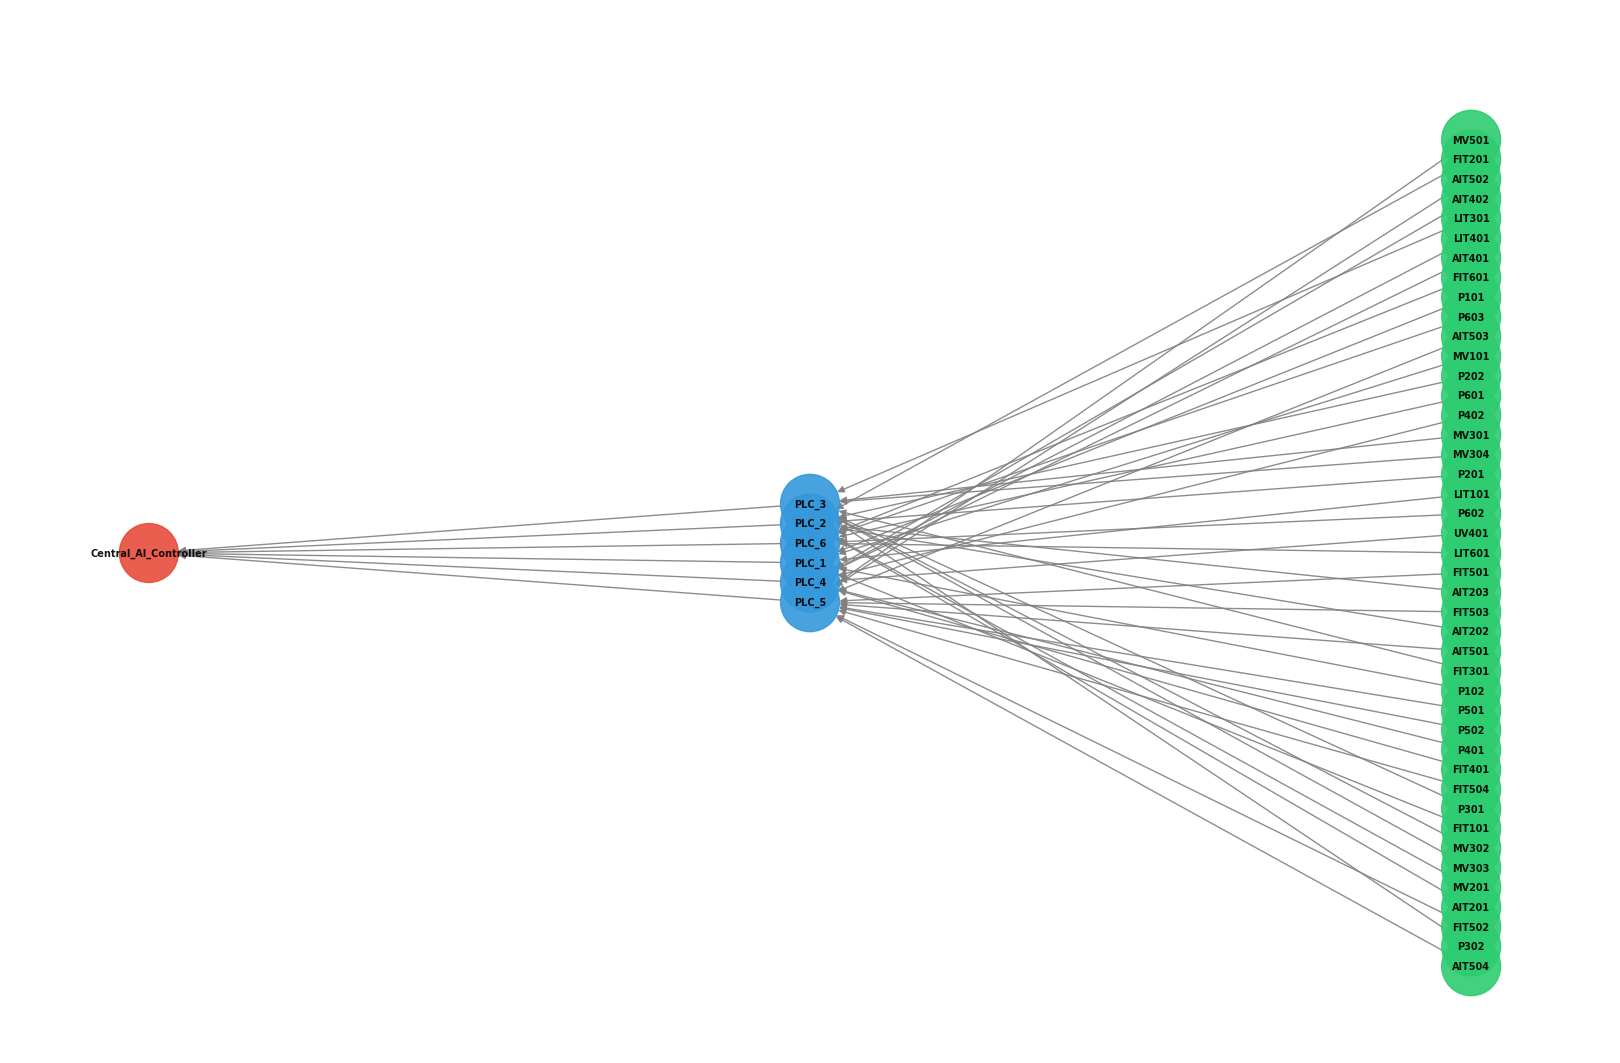

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ USER CONFIGURATION: SWAT TOPOLOGY
# ==========================================
print("Constructing Custom SWaT CPS Threat Graph...")
G = nx.DiGraph()

# Original mapping based on the 6 Stages of the SWaT Testbed
TOPOLOGY_MAPPING = {
    # STAGE 1: Raw Water Intake
    'FIT101': 'PLC_1', 'LIT101': 'PLC_1', 'MV101': 'PLC_1', 'P101': 'PLC_1', 'P102': 'PLC_1',
    # STAGE 2: Pre-Treatment (Chemical Dosing)
    'AIT201': 'PLC_2', 'AIT202': 'PLC_2', 'AIT203': 'PLC_2', 'FIT201': 'PLC_2', 'MV201': 'PLC_2', 'P201': 'PLC_2', 'P202': 'PLC_2',
    # STAGE 3: Ultrafiltration
    'FIT301': 'PLC_3', 'LIT301': 'PLC_3', 'MV301': 'PLC_3', 'MV302': 'PLC_3', 'MV303': 'PLC_3', 'MV304': 'PLC_3', 'P301': 'PLC_3', 'P302': 'PLC_3',
    # STAGE 4: De-chlorination
    'AIT401': 'PLC_4', 'AIT402': 'PLC_4', 'FIT401': 'PLC_4', 'LIT401': 'PLC_4', 'P401': 'PLC_4', 'P402': 'PLC_4', 'UV401': 'PLC_4',
    # STAGE 5: Reverse Osmosis
    'AIT501': 'PLC_5', 'AIT502': 'PLC_5', 'AIT503': 'PLC_5', 'AIT504': 'PLC_5', 'FIT501': 'PLC_5', 'FIT502': 'PLC_5', 'FIT503': 'PLC_5', 'FIT504': 'PLC_5', 'P501': 'PLC_5', 'P502': 'PLC_5', 'MV501': 'PLC_5',
    # STAGE 6: Distribution
    'FIT601': 'PLC_6', 'LIT601': 'PLC_6', 'P601': 'PLC_6', 'P602': 'PLC_6', 'P603': 'PLC_6'
}

# --- Add Nodes with Layer Attributes ---
# Physical Layer (Sensors/Actuators)
for component in TOPOLOGY_MAPPING.keys():
    G.add_node(component, layer='Physical')

# Network Layer (PLCs)
plcs = list(set(TOPOLOGY_MAPPING.values()))
for plc in plcs:
    G.add_node(plc, layer='Network')

# AI Layer (Central Defender)
G.add_node('Central_AI_Controller', layer='AI')

# --- Draw Edges (Information Flow) ---
# Edges from Sensors to PLCs
for sensor, plc in TOPOLOGY_MAPPING.items():
    G.add_edge(sensor, plc)

# Edges from PLCs to Central AI
for plc in plcs:
    G.add_edge(plc, 'Central_AI_Controller')

# ==========================================
# 🎨 VISUALIZATION SETTINGS
# ==========================================
plt.figure(figsize=(16, 10))

# Use multipartite layout to separate layers vertically
pos = nx.multipartite_layout(G, subset_key="layer")

# Define layer colors
TOPOLOGY_COLORS = {
    'Physical': '#2ecc71', # Green
    'Network': '#3498db',  # Blue
    'AI': '#e74c3c'        # Red
}

node_colors = [TOPOLOGY_COLORS[G.nodes[n]['layer']] for n in G.nodes]

# Draw the graph
nx.draw(G, pos, 
        with_labels=True, 
        node_color=node_colors, 
        node_size=1800,
        font_size=7, 
        font_color='black', 
        font_weight='bold', 
        arrows=True,
        edge_color='gray',
        alpha=0.9)

# Legend/Title
plt.title("SWaT Hierarchical Threat Model: Sensors → PLCs → AI", fontsize=16, pad=20)
plt.show()

In [6]:
# ==========================================
# BUILD & TRAIN THE LSTM AUTOENCODER (DEFENDER)
# ==========================================
print("Building LSTM Autoencoder (Defender)...")

n_features = len(SENSOR_COLUMNS)

# Encoder
inputs = keras.Input(shape=(SEQ_LENGTH, n_features))
encoded = layers.LSTM(64, activation='relu', return_sequences=True)(inputs)
encoded = layers.LSTM(32, activation='relu', return_sequences=False)(encoded)

# Decoder
decoded = layers.RepeatVector(SEQ_LENGTH)(encoded)
decoded = layers.LSTM(32, activation='relu', return_sequences=True)(decoded)
decoded = layers.LSTM(64, activation='relu', return_sequences=True)(decoded)
outputs = layers.TimeDistributed(layers.Dense(n_features))(decoded)

defender = Model(inputs, outputs)
defender.compile(optimizer='adam', loss='mse')

defender.summary()

# Train the defender on NORMAL data only (unsupervised anomaly detection)
print("\nTraining the Defender on normal data...")
history = defender.fit(
    X_train_seq, X_train_seq,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# Calculate anomaly detection threshold from training reconstruction error
print("\nCalculating anomaly detection threshold...")
train_preds = defender.predict(X_train_seq, batch_size=512, verbose=0)
train_mse = np.mean(np.square(X_train_seq - train_preds), axis=(1, 2))
threshold_95 = np.percentile(train_mse, 95)
print(f"\u2705 Anomaly Detection Threshold (95th percentile): {threshold_95:.6f}")
print(f"\u2705 Defender model ready.")


Building LSTM Autoencoder (Defender)...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 51)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 5, 64)          │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 5, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 5, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 51)          │         3,315 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,579 (306.95 KB)

 Trainable params: 78,579 (306.95 KB)

 Non-trainable params: 0 (0.00 B)


Training the Defender on normal data...
Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - loss: 0.3505 - val_loss: 0.2368
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.2210 - val_loss: 0.1883
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.1961 - val_loss: 0.1656
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.1720 - val_loss: 0.1588
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - loss: 0.1660 - val_loss: 0.1431
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.1503 - val_loss: 0.1243
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - loss: 0.1599 - val_loss: 0.1365
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.1263 - val_loss: 0.1185
Epoch 9/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - loss: 0.1139 - val_loss: 0.1192
Epoch 10/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.1069 - val_loss: 0.0985

Calculating anomaly detection threshold...
✅ Anomaly Detection Threshold (95t

Generating Comprehensive Performance Graphs...


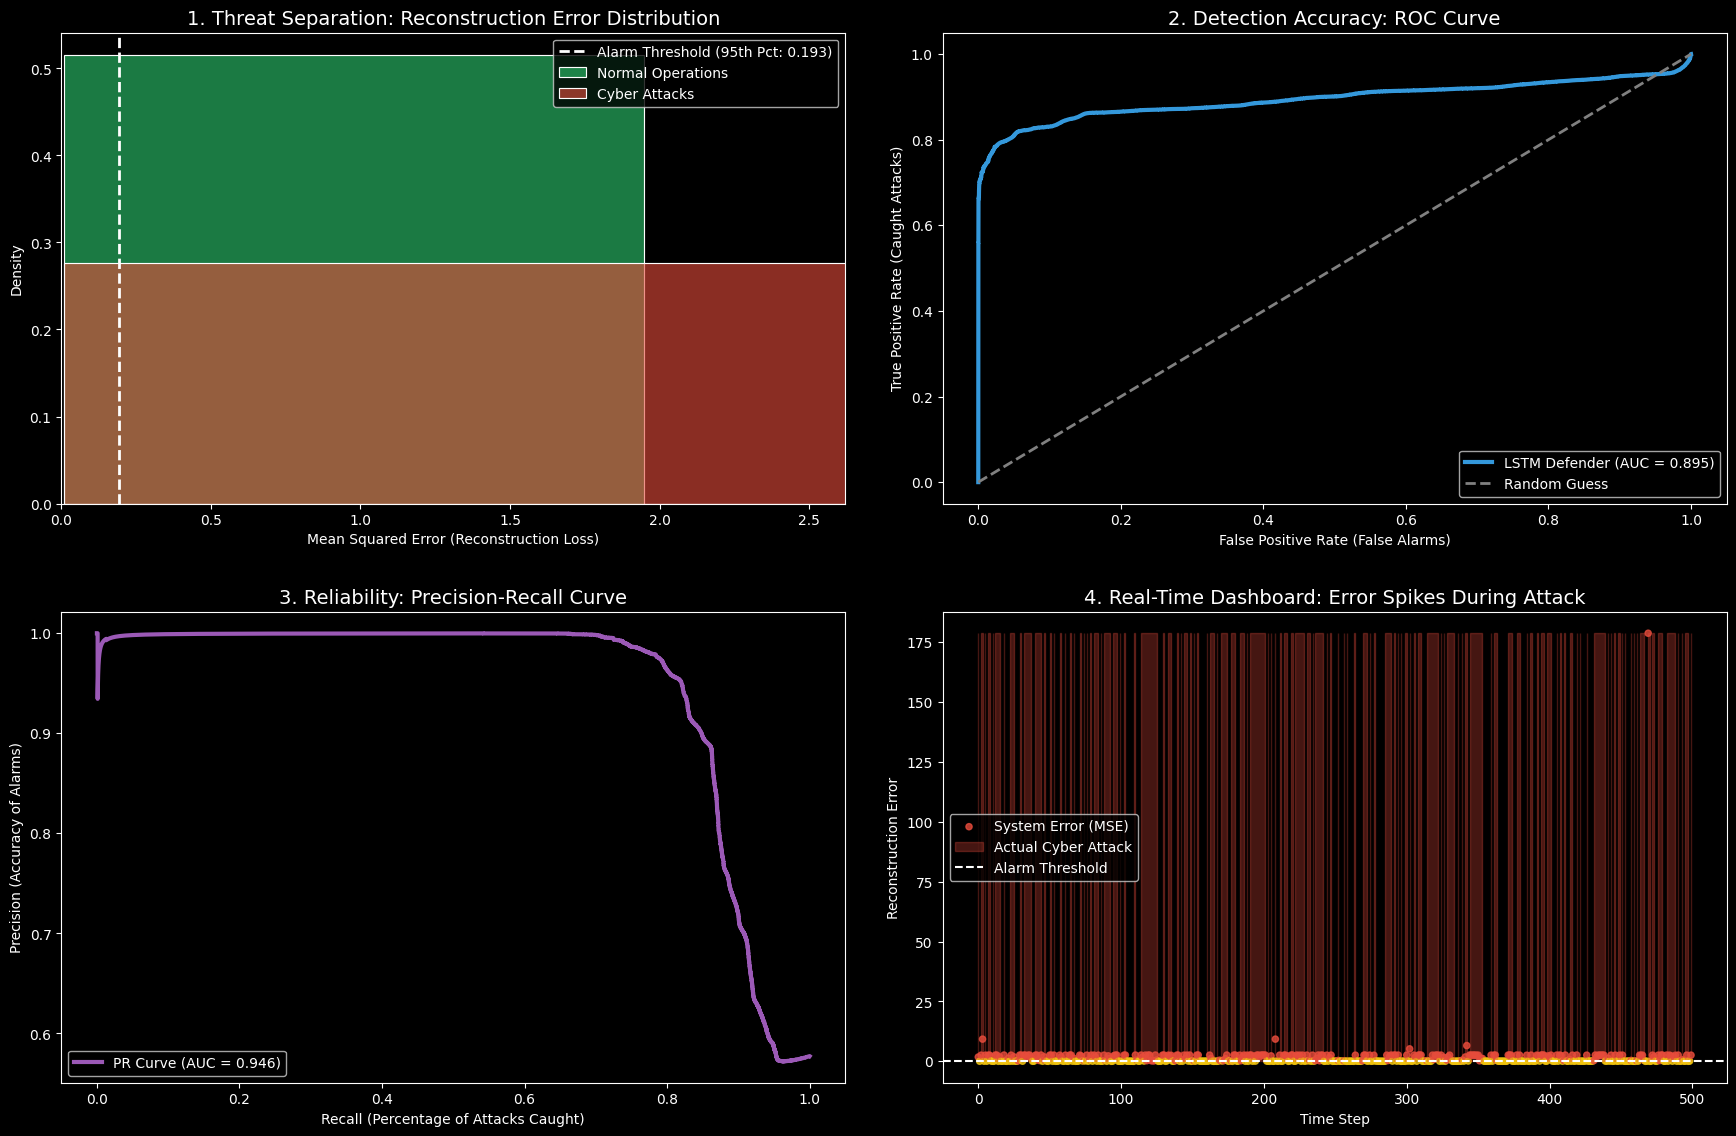

In [7]:
# ==========================================
# LSTM DEFENDER: COMPREHENSIVE VISUAL REPORT
# ==========================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import seaborn as sns

print("Generating Comprehensive Performance Graphs...")

# 1. Get Predictions on the mixed Test Set
test_preds = defender.predict(X_test_seq, batch_size=512, verbose=0)
test_mse = np.mean(np.square(X_test_seq - test_preds), axis=(1, 2))

# 2. Setup Figure Canvas
fig = plt.figure(figsize=(18, 12))
plt.style.use('dark_background')

# ---------------------------------------------------------
# GRAPH 1: Reconstruction Error Distribution (Histogram)
# ---------------------------------------------------------
# This proves how well your AI separates normal data from attacks
ax1 = plt.subplot(2, 2, 1)
sns.histplot(test_mse[y_test == 0], bins=50, color=COLORS['normal'], label='Normal Operations', stat='density', alpha=0.6, ax=ax1)
sns.histplot(test_mse[y_test == 1], bins=50, color=COLORS['attack'], label='Cyber Attacks', stat='density', alpha=0.6, ax=ax1)
ax1.axvline(threshold_95, color='white', linestyle='--', linewidth=2, label=f'Alarm Threshold (95th Pct: {threshold_95:.3f})')
ax1.set_title("1. Threat Separation: Reconstruction Error Distribution", fontsize=14, color='white')
ax1.set_xlabel("Mean Squared Error (Reconstruction Loss)")
ax1.set_ylabel("Density")
# Zoom in on the critical boundary to prevent massive outlier distortion
ax1.set_xlim(0, np.percentile(test_mse, 98))
ax1.legend()

# ---------------------------------------------------------
# GRAPH 2: ROC Curve (Receiver Operating Characteristic)
# ---------------------------------------------------------
# Shows the trade-off between catching attacks and triggering false alarms
ax2 = plt.subplot(2, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, test_mse)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color=COLORS['layer1'], lw=3, label=f'LSTM Defender (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
ax2.set_title("2. Detection Accuracy: ROC Curve", fontsize=14, color='white')
ax2.set_xlabel("False Positive Rate (False Alarms)")
ax2.set_ylabel("True Positive Rate (Caught Attacks)")
ax2.legend(loc="lower right")

# ---------------------------------------------------------
# GRAPH 3: Precision-Recall Curve
# ---------------------------------------------------------
# Critical for anomaly detection where normal data heavily outweighs attack data
ax3 = plt.subplot(2, 2, 3)
precision, recall, pr_thresholds = precision_recall_curve(y_test, test_mse)
pr_auc = auc(recall, precision)

ax3.plot(recall, precision, color=COLORS['layer3'], lw=3, label=f'PR Curve (AUC = {pr_auc:.3f})')
ax3.set_title("3. Reliability: Precision-Recall Curve", fontsize=14, color='white')
ax3.set_xlabel("Recall (Percentage of Attacks Caught)")
ax3.set_ylabel("Precision (Accuracy of Alarms)")
ax3.legend(loc="lower left")

# ---------------------------------------------------------
# GRAPH 4: Time-Series Anomaly Overlay
# ---------------------------------------------------------
# A real-world view of the data over time with attacks highlighted
ax4 = plt.subplot(2, 2, 4)

# Plot a 1000-timestep slice that contains an attack
attack_indices = np.where(y_test == 1)[0]
if len(attack_indices) > 0:
    start_idx = max(0, attack_indices[0] - 500)
    end_idx = min(len(y_test), attack_indices[0] + 500)

    # Plot the reconstruction error over time
    time_steps = range(start_idx, end_idx)
    # Changed to scatter plot for better visual understanding
    mse_slice = test_mse[start_idx:end_idx]
    point_colors = np.where(mse_slice > threshold_95, COLORS['attack'], COLORS['layer2'])
    ax4.scatter(time_steps, mse_slice, color=point_colors, label='System Error (MSE)', s=20, alpha=0.8)

    # Shade the actual attack windows in red
    ax4.fill_between(time_steps, 0, max(test_mse[start_idx:end_idx]),
                     where=(y_test[start_idx:end_idx] == 1),
                     color=COLORS['attack'], alpha=0.3, label='Actual Cyber Attack')

    # Draw the threshold line
    ax4.axhline(threshold_95, color='white', linestyle='--', label='Alarm Threshold')

    ax4.set_title("4. Real-Time Dashboard: Error Spikes During Attack", fontsize=14, color='white')
    ax4.set_xlabel("Time Step")
    ax4.set_ylabel("Reconstruction Error")
    ax4.legend()
else:
    ax4.text(0.5, 0.5, "No attacks in test set to display", ha='center', color='white')

plt.tight_layout(pad=3.0)
plt.show()

Calculating Metrics based on Anomaly Detection Threshold...
Accuracy:  0.8688
Precision: 0.9567
Recall:    0.8094
F1 Score:  0.8769



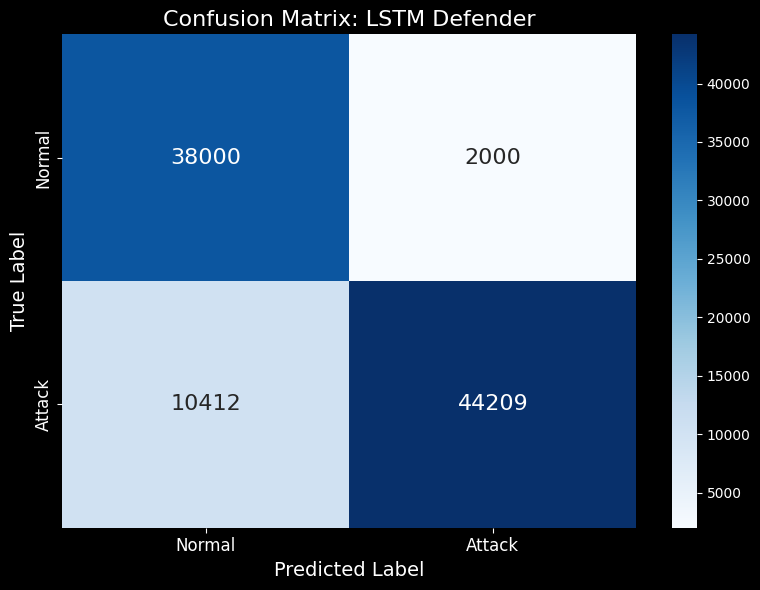

In [8]:
# ==========================================
# CONFUSION MATRIX & MODEL METRICS
# ==========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

print("Calculating Metrics based on Anomaly Detection Threshold...")

# Convert MSE to binary predictions based on the 95th percentile threshold
y_pred = (test_mse > threshold_95).astype(int)

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}\n")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'],
            annot_kws={"size": 16})

plt.title("Confusion Matrix: LSTM Defender", color='white', fontsize=16)
plt.xlabel("Predicted Label", color='white', fontsize=14)
plt.ylabel("True Label", color='white', fontsize=14)
# Make ticks white to match dark background
plt.xticks(color='white', fontsize=12)
plt.yticks(color='white', fontsize=12)

plt.tight_layout()
plt.show()



STARTING EXTENDED CO-EVOLUTIONARY ARMS RACE (9 ROUNDS)

[ROUND 1]
-> Attacker evolving: Launching Stealth Variants (Epsilon 0.03)...
-> System Risk Score: 0.1890 (378/2000 attacks bypassed IDS)
-> Defender adapting and patching blind spots...

[ROUND 2]
-> Attacker evolving: Launching Stealth Variants (Epsilon 0.06)...
-> System Risk Score: 0.6915 (1383/2000 attacks bypassed IDS)
-> Defender adapting and patching blind spots...

[ROUND 3]
-> Attacker evolving: Launching Stealth Variants (Epsilon 0.09)...
-> System Risk Score: 0.6885 (1377/2000 attacks bypassed IDS)
-> Defender adapting and patching blind spots...

[ROUND 4]
-> Attacker evolving: Launching Stealth Variants (Epsilon 0.12)...
-> System Risk Score: 0.6640 (1328/2000 attacks bypassed IDS)
-> Defender adapting and patching blind spots...

[ROUND 5]
-> Attacker evolving: Launching Stealth Variants (Epsilon 0.15)...
-> System Risk Score: 0.5950 (1190/2000 attacks bypassed IDS)
-> Defender adapting and patching blind spots...


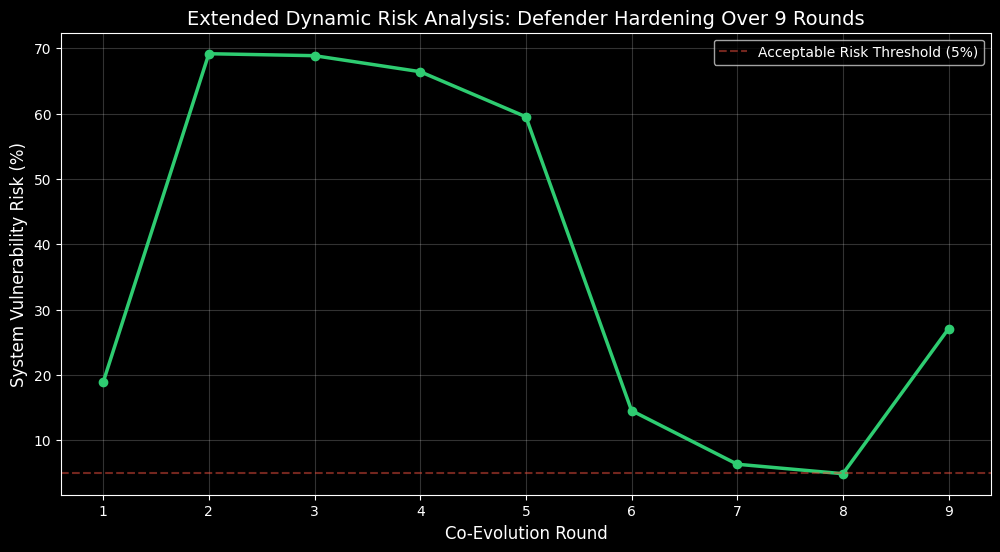

In [9]:
def generate_stealth_attack(model, base_sequences, epsilon):
    """FGSM Attacker: Uses gradients to generate invisible noise."""
    inputs = tf.convert_to_tensor(base_sequences, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(inputs)
        reconstructions = model(inputs)
        loss = tf.reduce_mean(tf.square(inputs - reconstructions))

    gradients = tape.gradient(loss, inputs)
    perturbation = epsilon * tf.sign(gradients)
    return (inputs + perturbation).numpy()

# ==========================================
# ⚙️ EXTENDED ARMS RACE CONFIGURATION
# ==========================================
ROUNDS = 9  # Increased from 4 to 10 rounds to let the defender win
system_risk_history = []

# Get a sample of actual attacks from your dataset to base the simulation on
attack_indices = np.where(y_test == 1)[0]
if len(attack_indices) == 0:
    raise ValueError("No attack data found in the test set. Cannot run simulation.")

# Limit to 2000 attacks for the simulation to prevent Colab GPU OOM
sample_size = min(2000, len(attack_indices))
actual_attacks_seq = X_test_seq[np.random.choice(attack_indices, sample_size, replace=False)]

print("\n" + "="*60)
print(f"STARTING EXTENDED CO-EVOLUTIONARY ARMS RACE ({ROUNDS} ROUNDS)")
print("="*60)

for round_num in range(1, ROUNDS + 1):
    print(f"\n[ROUND {round_num}]")

    # 1. THE ATTACK (Adversarial Engine)
    # We use 'min' to cap the epsilon at 0.25.
    # In the real world, if an attacker injects too much noise, physical alarms trip automatically.
    dynamic_epsilon = min(0.03 * round_num, 0.20)

    print(f"-> Attacker evolving: Launching Stealth Variants (Epsilon {dynamic_epsilon:.2f})...")
    stealth_attacks = generate_stealth_attack(defender, actual_attacks_seq, epsilon=dynamic_epsilon)

    # 2. EVALUATE PHYSICAL RISK
    stealth_preds = defender.predict(stealth_attacks, verbose=0)
    stealth_mse = np.mean(np.square(stealth_attacks - stealth_preds), axis=(1, 2))

    bypassed_count = np.sum(stealth_mse < threshold_95)
    system_risk = bypassed_count / len(stealth_attacks)
    system_risk_history.append(system_risk)

    print(f"-> System Risk Score: {system_risk:.4f} ({bypassed_count}/{len(stealth_attacks)} attacks bypassed IDS)")

    # 3. THE DEFENSE (Retraining)
    if round_num < ROUNDS:
        print("-> Defender adapting and patching blind spots...")
        # Train on a mix of normal data and the new stealth attacks
        retrain_x = np.vstack([X_train_seq[:3000], stealth_attacks])
        # We give the defender slightly more epochs (5 instead of 3) to learn the complex new attacks
        defender.fit(retrain_x, retrain_x, epochs=5, batch_size=128, verbose=0)

# Plot the Extended Arms Race Results
plt.figure(figsize=(12, 6))
plt.plot(range(1, ROUNDS + 1), [risk * 100 for risk in system_risk_history], marker='o', color=COLORS['normal'], linewidth=2.5)

# Add a trendline to show the defender winning
plt.axhline(y=5, color=COLORS['attack'], linestyle='--', alpha=0.5, label="Acceptable Risk Threshold (5%)")

plt.title(f"Extended Dynamic Risk Analysis: Defender Hardening Over {ROUNDS} Rounds", color='white', fontsize=14)
plt.xlabel("Co-Evolution Round", color='white', fontsize=12)
plt.ylabel("System Vulnerability Risk (%)", color='white', fontsize=12)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Initializing SHAP for Attack Surface Explainability...
Generating SHAP explanations for 10 attacks...

Processing attack 1/10 (index=0)...


  0%|          | 0/1 [00:00<?, ?it/s]

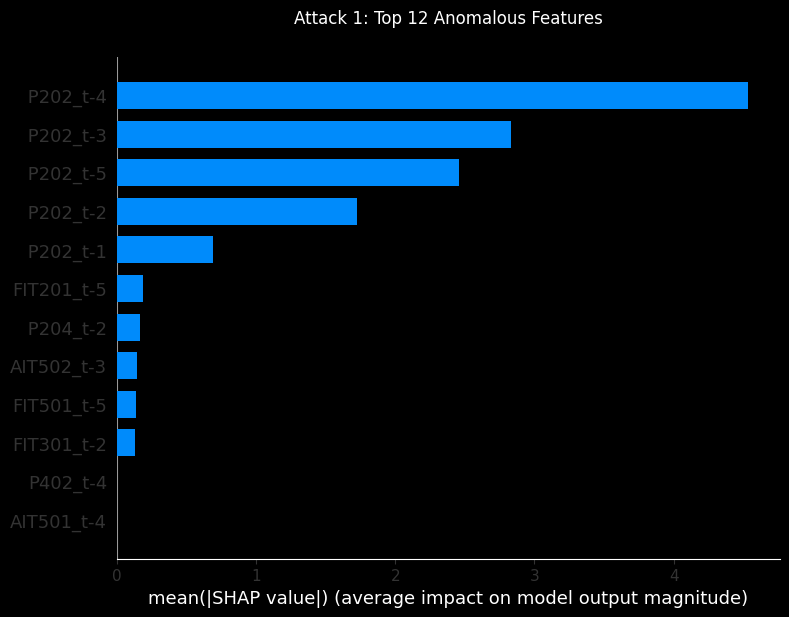

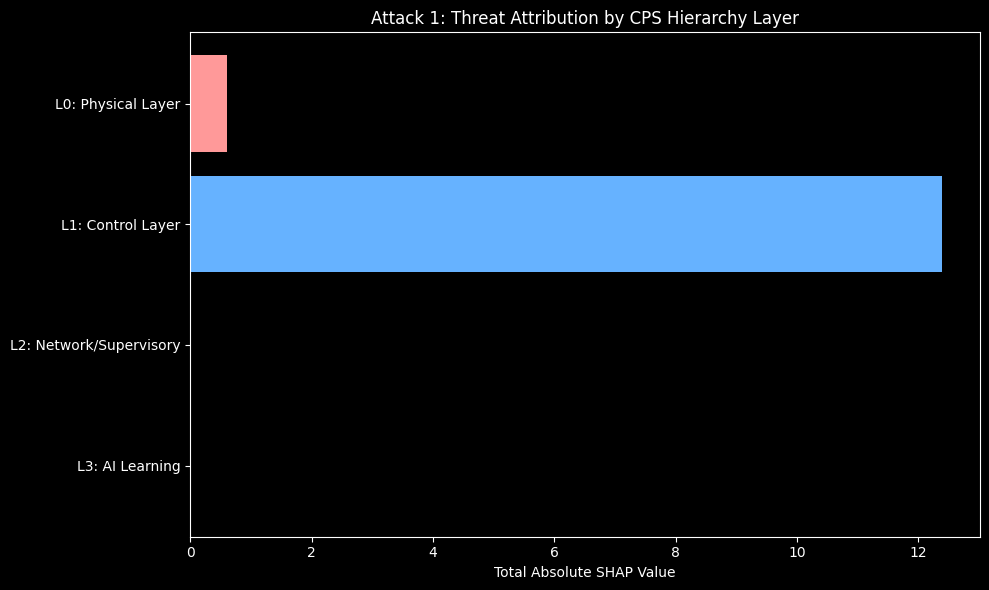

Processing attack 2/10 (index=2)...


  0%|          | 0/1 [00:00<?, ?it/s]

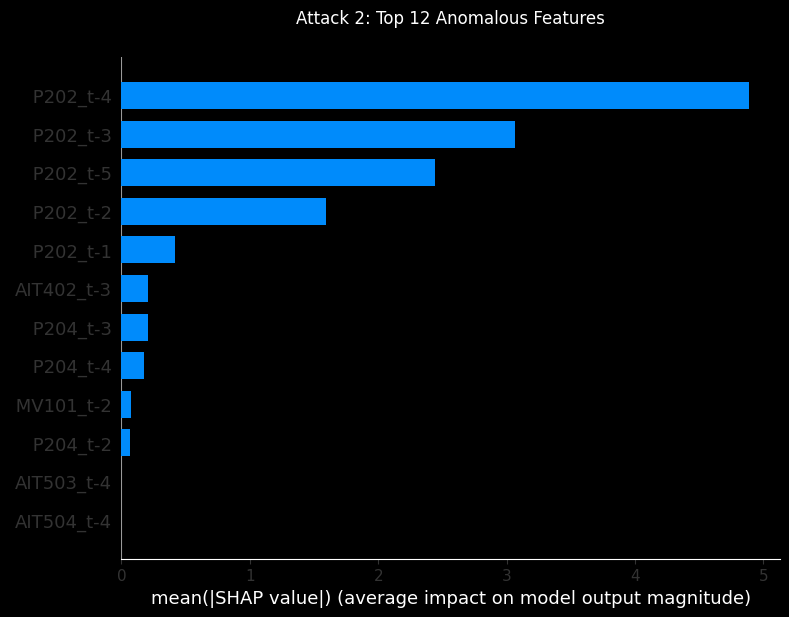

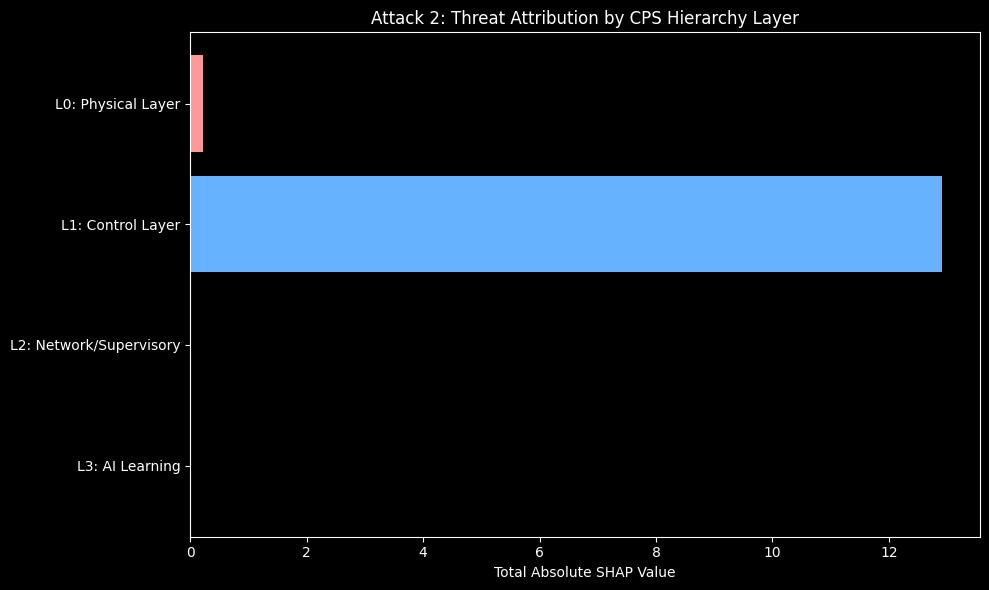

Processing attack 3/10 (index=3)...


  0%|          | 0/1 [00:00<?, ?it/s]

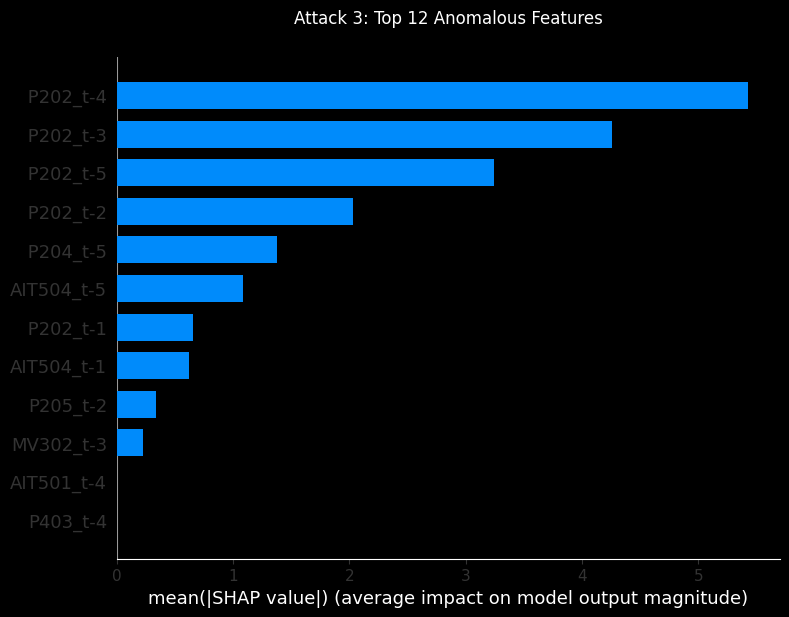

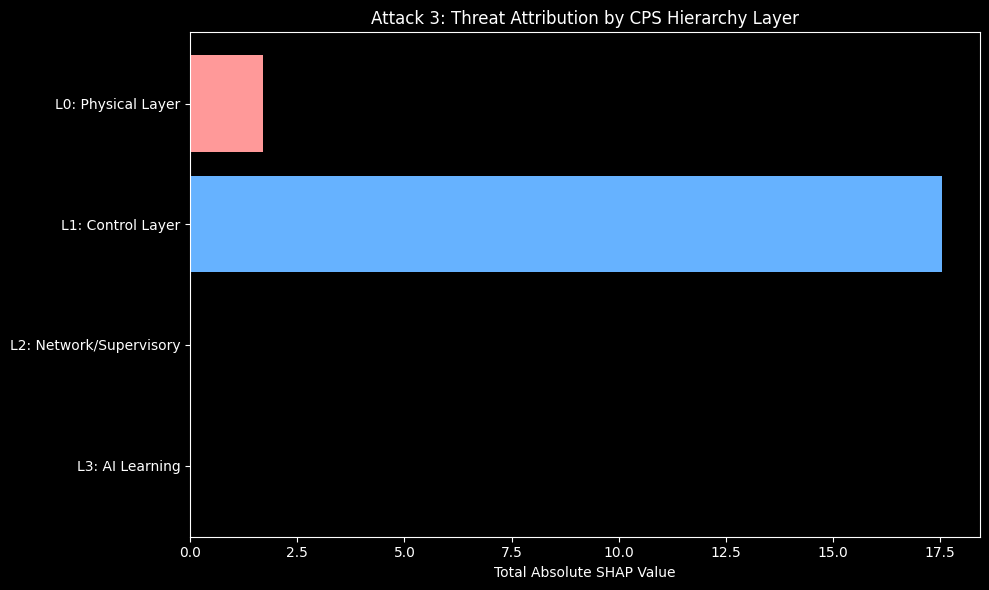

Processing attack 4/10 (index=5)...


  0%|          | 0/1 [00:00<?, ?it/s]

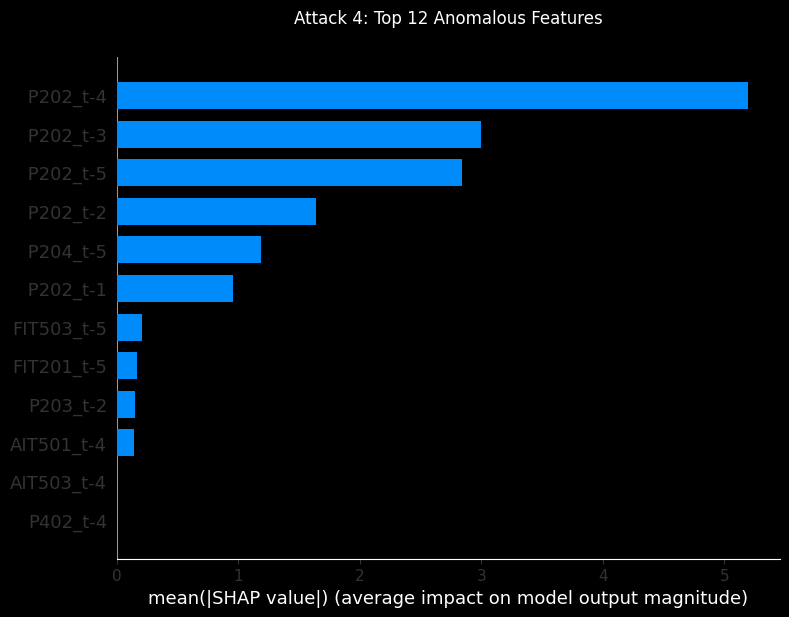

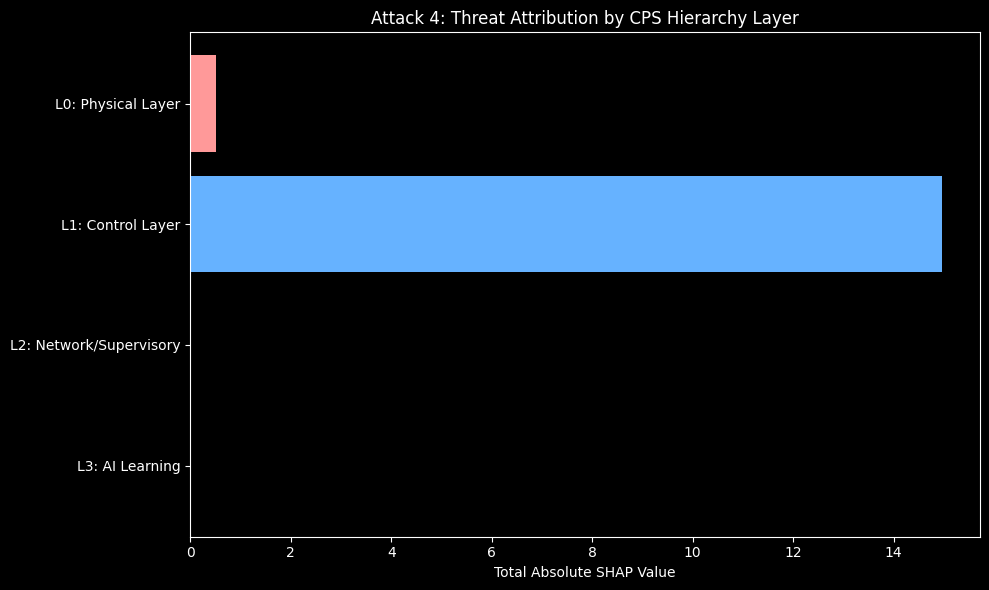

Processing attack 5/10 (index=7)...


  0%|          | 0/1 [00:00<?, ?it/s]

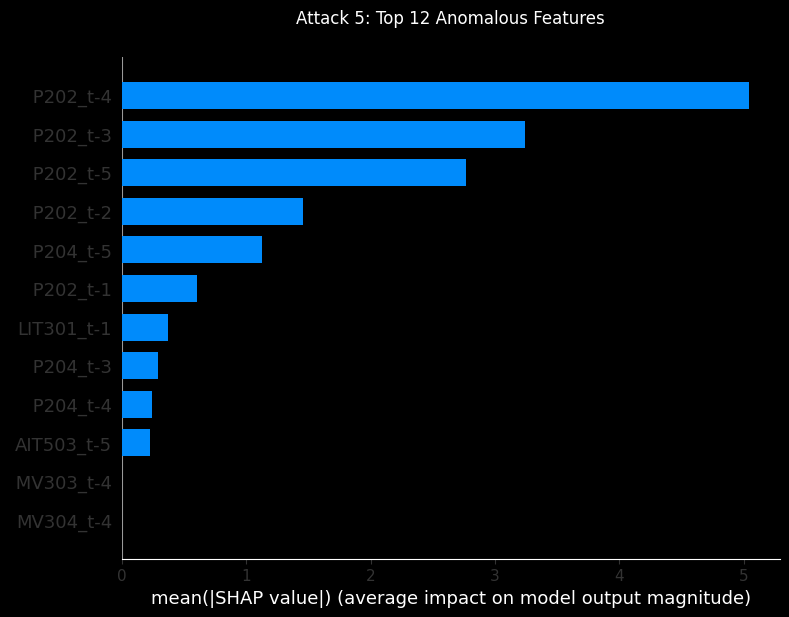

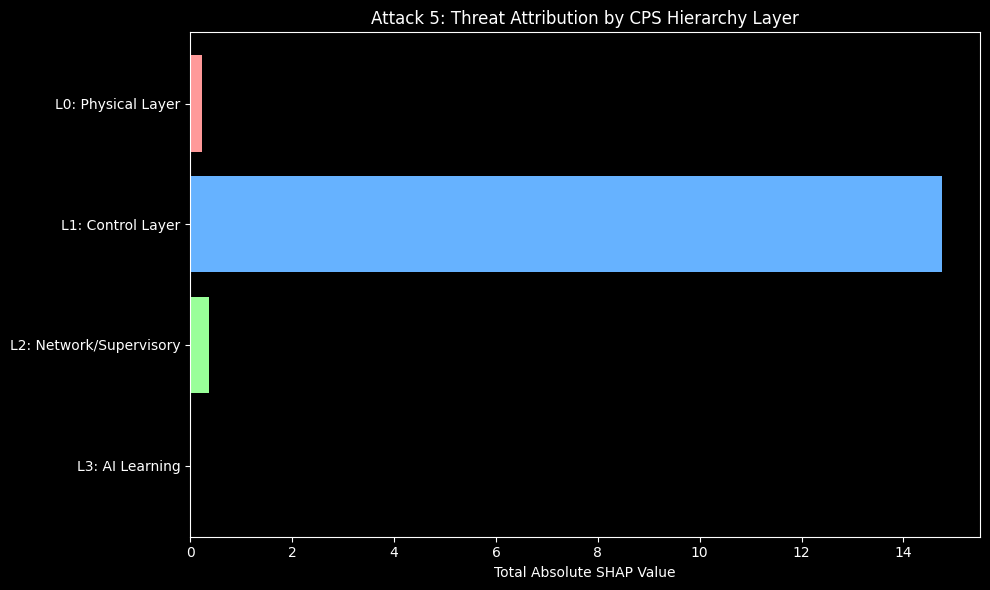

Processing attack 6/10 (index=8)...


  0%|          | 0/1 [00:00<?, ?it/s]

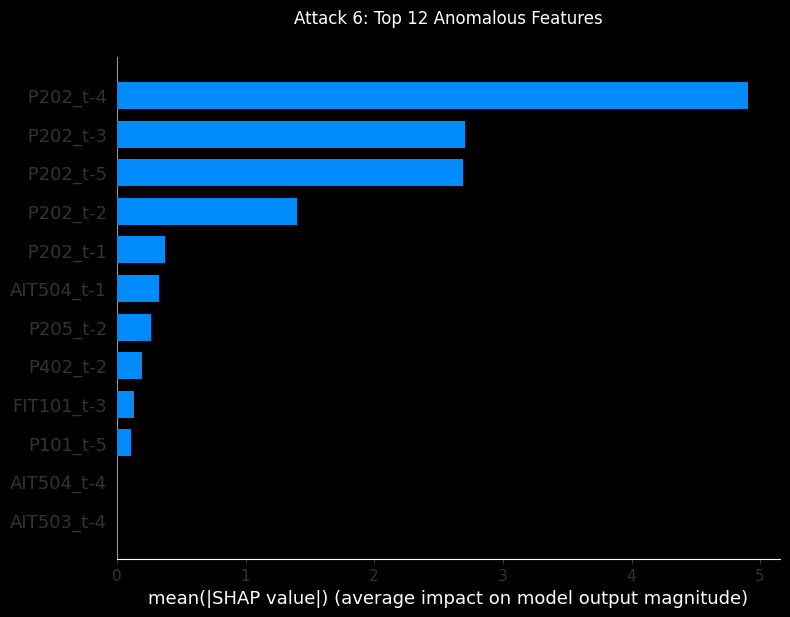

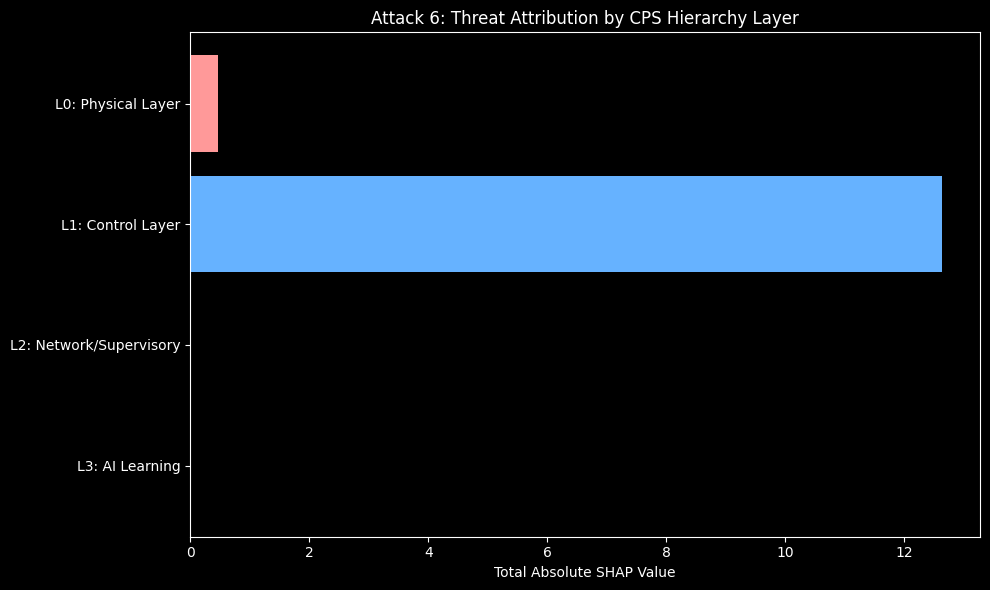

Processing attack 7/10 (index=10)...


  0%|          | 0/1 [00:00<?, ?it/s]

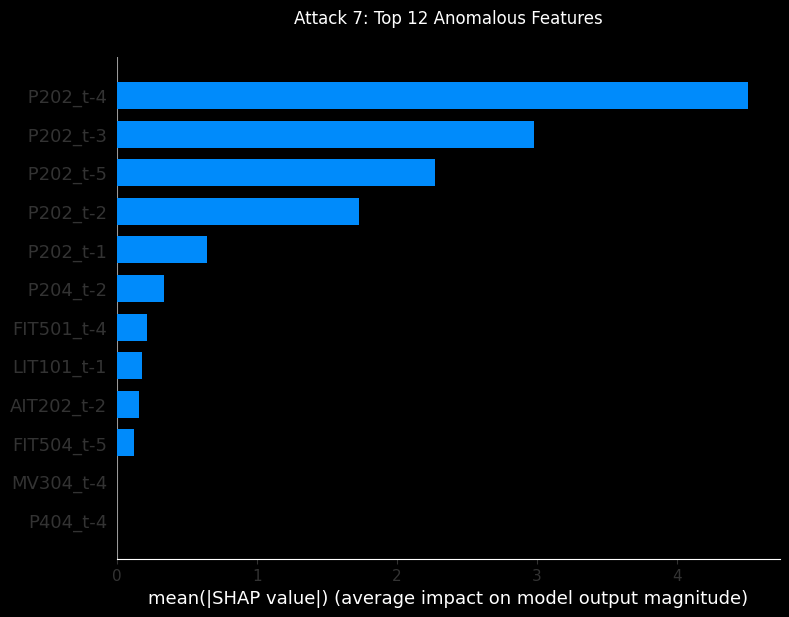

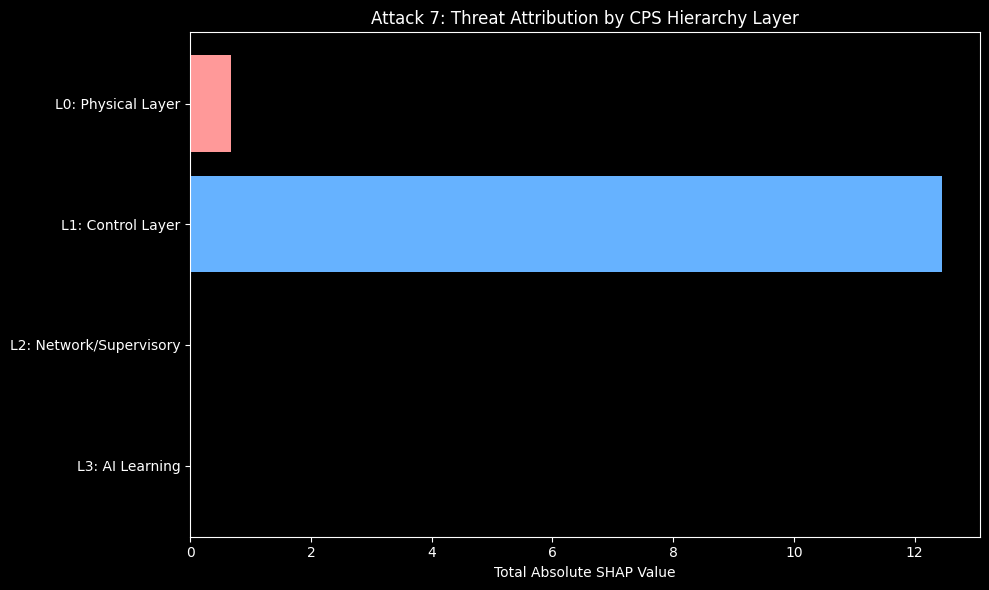

Processing attack 8/10 (index=12)...


  0%|          | 0/1 [00:00<?, ?it/s]

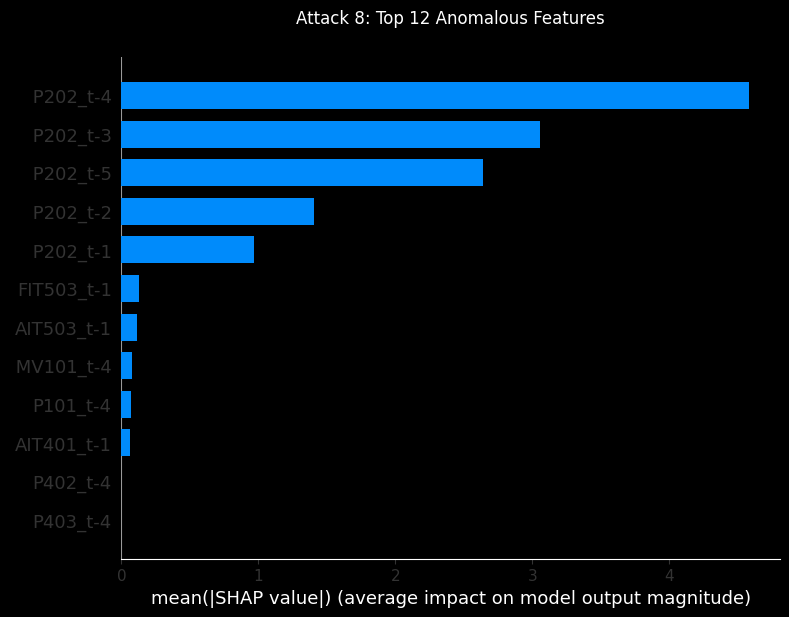

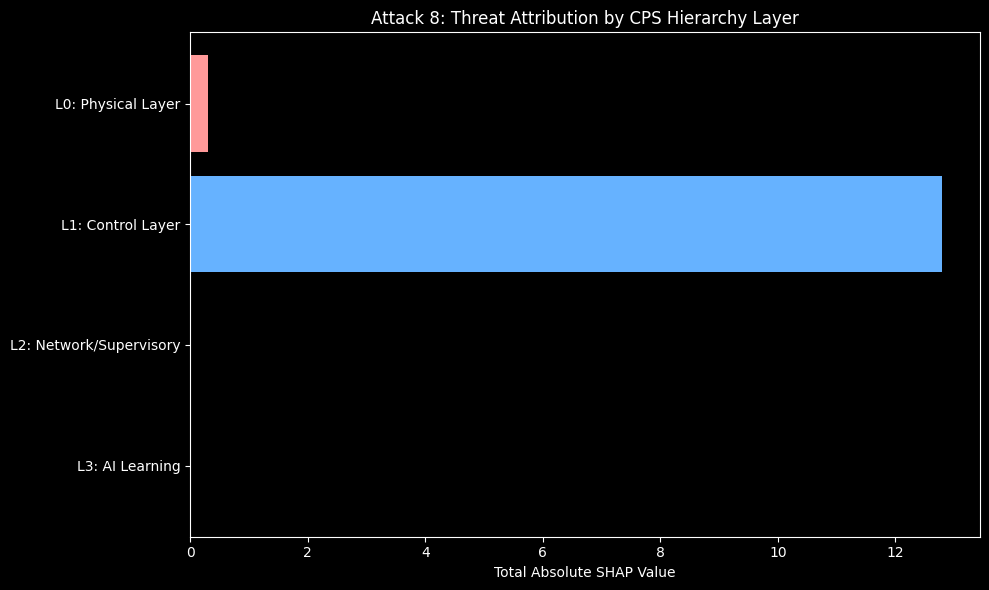

Processing attack 9/10 (index=13)...


  0%|          | 0/1 [00:00<?, ?it/s]

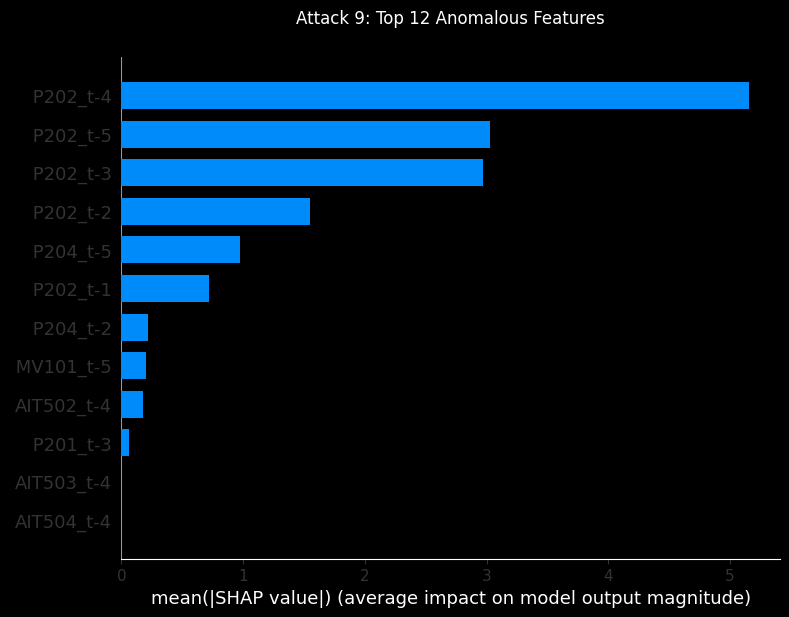

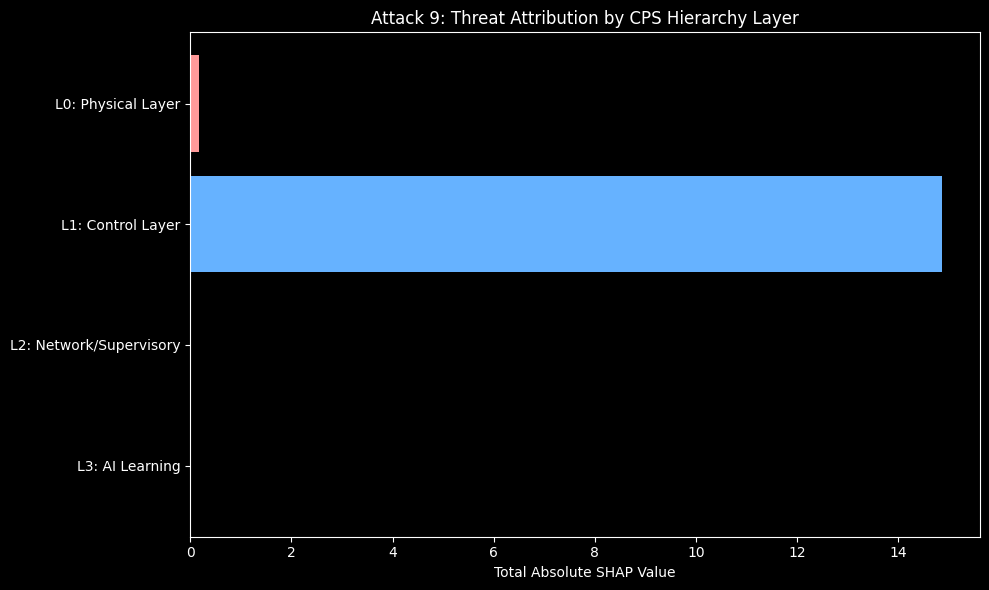

Processing attack 10/10 (index=14)...


  0%|          | 0/1 [00:00<?, ?it/s]

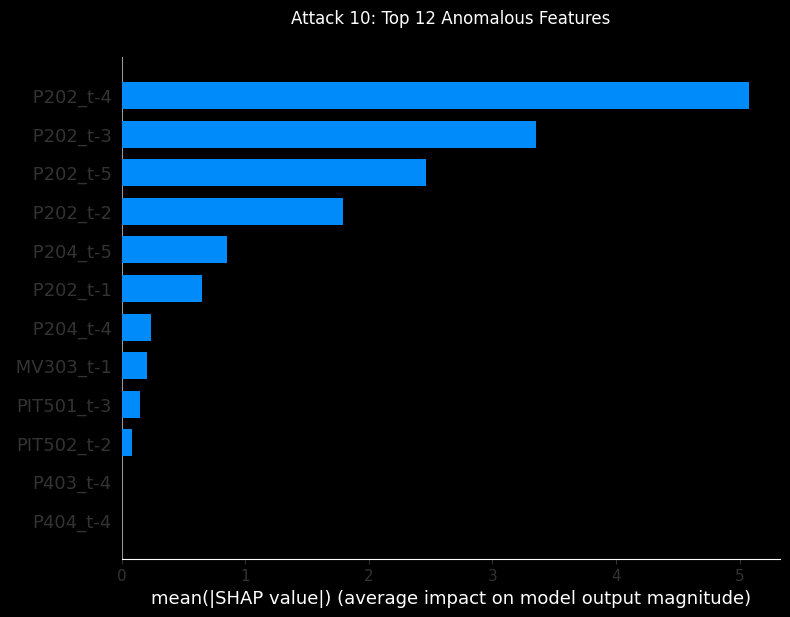

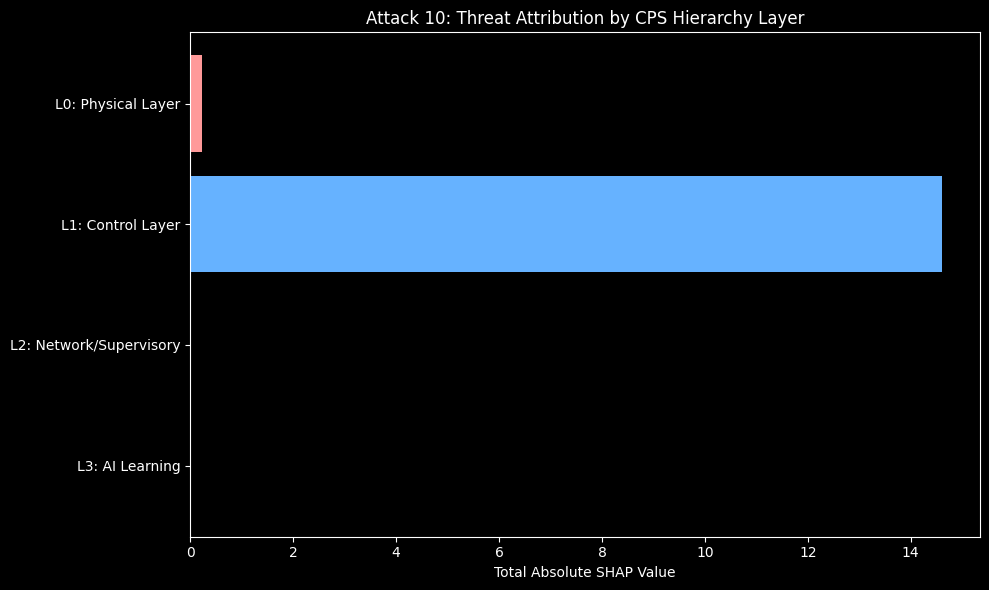


=== ALL ATTACK EXPLANATIONS COMPLETE ===


In [10]:
HIERARCHY_MAP = {
    "Level_0_Physical": {
        "name": "L0: Physical Layer",
        "description": "Local sensors and physical indicators",
        "features": [
            "FIT101", "LIT101", "AIT201", "AIT202", "AIT203", "FIT201", 
            "DPIT301", "FIT301", "AIT401", "AIT402", "AIT501", "AIT502", 
            "AIT503", "AIT504", "FIT501", "FIT502", "FIT503", "FIT504", 
            "PIT501", "PIT502", "PIT503", "FIT601"
        ]
    },
    "Level_1_Control": {
        "name": "L1: Control Layer",
        "description": "Local actuators and PLC execution logic",
        "features": [
            "MV101", "P101", "P102", "MV201", "P201", "P202", "P203", "P204", 
            "P205", "P206", "MV301", "MV302", "MV303", "MV304", "P301", "P302", 
            "P401", "P402", "P403", "P404", "UV401", "P501", "P502", "P601", "P602", "P603"
        ]
    },
    "Level_2_Network": {
        "name": "L2: Network/Supervisory",
        "description": "Inter-PLC synchronization and data exchange",
        "features": ["LIT301", "LIT401", "FIT401", "Timestamp"]
    },
    "Level_3_Learning": {
        "name": "L3: AI Learning",
        "description": "Digital Twin monitoring and SHAP attribution",
        "features": ["MAE", "SHAP_Values"]
    }
}

def attribute_threat(feature_name: str):
    if feature_name is None:
        return "Unknown", "No feature provided"
    key = feature_name.strip()
    for layer_id, info in HIERARCHY_MAP.items():
        if key in info["features"]:
            return layer_id, info["description"]
    return "Unknown", "Feature not found in hierarchy"

print("Initializing SHAP for Attack Surface Explainability...")

def lstm_wrapper(x_2d):
    x_3d = x_2d.reshape(-1, SEQ_LENGTH, len(SENSOR_COLUMNS))
    preds = defender.predict(x_3d, verbose=0)
    return np.mean(np.square(x_3d - preds), axis=(1, 2))

# Background data (keep small)
background = X_train_seq[:50].reshape(50, -1)
explainer = shap.KernelExplainer(lstm_wrapper, background)

# Feature names with time steps
seq_feature_names = [
    f"{feat}_t-{SEQ_LENGTH-i}"
    for i in range(SEQ_LENGTH)
    for feat in SENSOR_COLUMNS
]

print("Generating SHAP explanations for 10 attacks...\n")

# Limit to 10 attacks (or fewer if not enough exist)
num_attacks = min(3, len(attack_indices))

for i in range(num_attacks):
    idx = attack_indices[i]
    attack_sample = X_test_seq[idx:idx+1].reshape(1, -1)

    print(f"Processing attack {i+1}/{num_attacks} (index={idx})...")

    shap_values = explainer.shap_values(attack_sample)

    # Plot 1: Overall Feature Importance
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values,
        attack_sample,
        feature_names=seq_feature_names,
        plot_type="bar",
        max_display=12,
        show=False
    )
    plt.title(
        f"Attack {i+1}: Top 12 Anomalous Features",
        y=1.05
    )
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Level-wise Attribution
    layer_shap_sums = {}
    for layer_id in HIERARCHY_MAP.keys():
        layer_shap_sums[HIERARCHY_MAP[layer_id]["name"]] = 0.0
    
    for j, feat_name_time in enumerate(seq_feature_names):
        base_feat = feat_name_time.split("_t-")[0]
        layer_id, desc = attribute_threat(base_feat)
        if layer_id in HIERARCHY_MAP:
            layer_name = HIERARCHY_MAP[layer_id]["name"]
        else:
            layer_name = "Unknown"
            if layer_name not in layer_shap_sums:
                layer_shap_sums[layer_name] = 0.0
        
        layer_shap_sums[layer_name] += np.abs(shap_values[0][j])

    layers = list(layer_shap_sums.keys())
    sums = [layer_shap_sums[k] for k in layers]
    
    plt.figure(figsize=(10, 6))
    bars = plt.barh(layers, sums, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#D3D3D3'])
    plt.xlabel("Total Absolute SHAP Value")
    plt.title(f"Attack {i+1}: Threat Attribution by CPS Hierarchy Layer")
    plt.gca().invert_yaxis()  # Highest layer at the top
    plt.tight_layout()
    plt.show()

print("\n=== ALL ATTACK EXPLANATIONS COMPLETE ===")


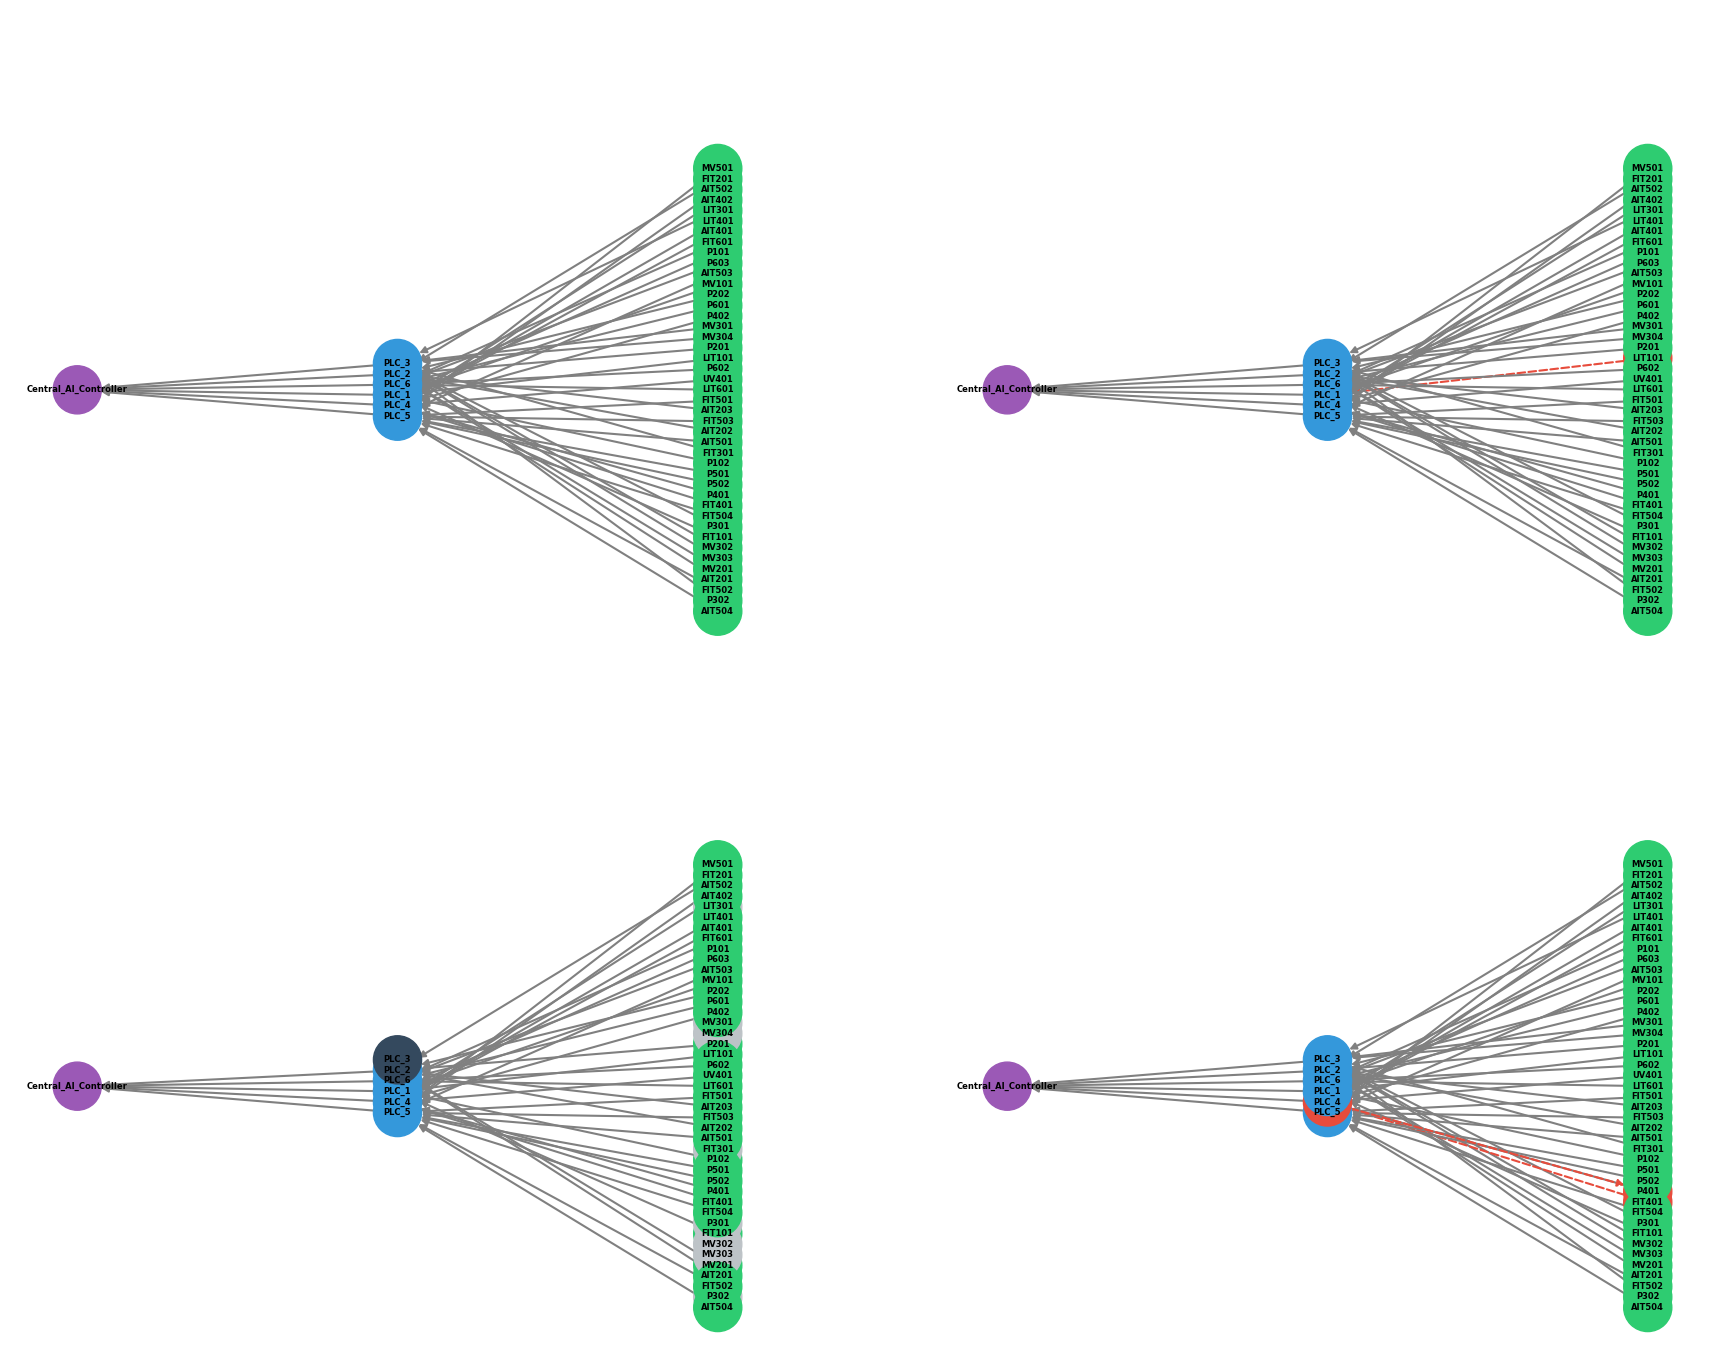

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
import copy

# ==========================================
# ⚙️ 1. BASE TOPOLOGY CONFIGURATION
# ==========================================
TOPOLOGY_MAPPING = {
    # STAGE 1: Raw Water Intake
    'FIT101': 'PLC_1', 'LIT101': 'PLC_1', 'MV101': 'PLC_1', 'P101': 'PLC_1', 'P102': 'PLC_1',
    # STAGE 2: Pre-Treatment (Chemical Dosing)
    'AIT201': 'PLC_2', 'AIT202': 'PLC_2', 'AIT203': 'PLC_2', 'FIT201': 'PLC_2', 'MV201': 'PLC_2', 'P201': 'PLC_2', 'P202': 'PLC_2',
    # STAGE 3: Ultrafiltration
    'FIT301': 'PLC_3', 'LIT301': 'PLC_3', 'MV301': 'PLC_3', 'MV302': 'PLC_3', 'MV303': 'PLC_3', 'MV304': 'PLC_3', 'P301': 'PLC_3', 'P302': 'PLC_3',
    # STAGE 4: De-chlorination
    'AIT401': 'PLC_4', 'AIT402': 'PLC_4', 'FIT401': 'PLC_4', 'LIT401': 'PLC_4', 'P401': 'PLC_4', 'P402': 'PLC_4', 'UV401': 'PLC_4',
    # STAGE 5: Reverse Osmosis
    'AIT501': 'PLC_5', 'AIT502': 'PLC_5', 'AIT503': 'PLC_5', 'AIT504': 'PLC_5', 'FIT501': 'PLC_5', 'FIT502': 'PLC_5', 'FIT503': 'PLC_5', 'FIT504': 'PLC_5', 'P501': 'PLC_5', 'P502': 'PLC_5', 'MV501': 'PLC_5',
    # STAGE 6: Distribution
    'FIT601': 'PLC_6', 'LIT601': 'PLC_6', 'P601': 'PLC_6', 'P602': 'PLC_6', 'P603': 'PLC_6'
}

def create_base_graph():
    """Builds the initial, healthy SWaT graph."""
    G = nx.DiGraph()
    
    # Add Nodes with default 'Normal' state
    for component in TOPOLOGY_MAPPING.keys():
        G.add_node(component, layer='Physical', state='Normal')
        
    plcs = list(set(TOPOLOGY_MAPPING.values()))
    for plc in plcs:
        G.add_node(plc, layer='Network', state='Normal')
        
    G.add_node('Central_AI_Controller', layer='AI', state='Normal')
    
    # Add Edges with default 'Normal' traffic state
    for sensor, plc in TOPOLOGY_MAPPING.items():
        G.add_edge(sensor, plc, traffic='Normal')
        
    for plc in plcs:
        G.add_edge(plc, 'Central_AI_Controller', traffic='Normal')
        
    return G

# ==========================================
# 🛡️ 2. ATTACK SIMULATION LOGIC
# ==========================================

def attack_fdi(G, target_sensor):
    """Simulates False Data Injection: Modifies sensor data heading to the PLC."""
    if target_sensor in G.nodes:
        G.nodes[target_sensor]['state'] = 'Compromised'
        # Corrupt the data flow from sensor to its PLC
        successors = list(G.successors(target_sensor))
        for succ in successors:
            G.edges[target_sensor, succ]['traffic'] = 'Malicious'

def attack_dos(G, target_plc):
    """Simulates Denial of Service: Knocks a PLC offline, dropping connections."""
    if target_plc in G.nodes:
        G.nodes[target_plc]['state'] = 'Offline'
        # Drop incoming connections from physical layer
        predecessors = list(G.predecessors(target_plc))
        for pred in predecessors:
            G.edges[pred, target_plc]['traffic'] = 'Blocked'
            G.nodes[pred]['state'] = 'Isolated' # Sensors are orphaned
            
        # Drop outgoing connections to AI
        successors = list(G.successors(target_plc))
        for succ in successors:
            G.edges[target_plc, succ]['traffic'] = 'Blocked'

def attack_command_injection(G, target_actuator, target_plc):
    """Simulates PLC compromise leading to malicious actuator commands."""
    if target_plc in G.nodes and target_actuator in G.nodes:
        G.nodes[target_plc]['state'] = 'Compromised'
        G.nodes[target_actuator]['state'] = 'Compromised'
        # Malicious command flows backwards (from PLC to actuator)
        # We add a reverse edge to simulate command flow overriding telemetry
        G.add_edge(target_plc, target_actuator, traffic='Malicious_Command')

# ==========================================
# 🎨 3. VISUALIZATION ENGINE
# ==========================================

def draw_threat_state(G, ax, title):
    """Renders the graph based on the current health state of nodes and edges."""
    pos = nx.multipartite_layout(G, subset_key="layer")
    
    # Node Color Logic
    node_colors = []
    for node, data in G.nodes(data=True):
        if data['state'] == 'Normal':
            if data['layer'] == 'Physical': node_colors.append('#2ecc71') # Green
            elif data['layer'] == 'Network': node_colors.append('#3498db') # Blue
            else: node_colors.append('#9b59b6') # Purple for AI
        elif data['state'] == 'Compromised':
            node_colors.append('#e74c3c') # Red for Hacked
        elif data['state'] == 'Offline':
            node_colors.append('#34495e') # Dark Grey for DoS
        elif data['state'] == 'Isolated':
            node_colors.append('#bdc3c7') # Light Grey for orphaned sensors
            
    # Edge Color & Style Logic
    edge_colors = []
    edge_styles = []
    for u, v, data in G.edges(data=True):
        if data['traffic'] == 'Normal':
            edge_colors.append('gray')
            edge_styles.append('solid')
        elif data['traffic'] == 'Malicious' or data['traffic'] == 'Malicious_Command':
            edge_colors.append('#e74c3c') # Red Data Flow
            edge_styles.append('dashed')
        elif data['traffic'] == 'Blocked':
            edge_colors.append('none') # Invisible edge to simulate drop
            edge_styles.append('dotted')

    nx.draw(G, pos, ax=ax, with_labels=True, 
            node_color=node_colors, edge_color=edge_colors, style=edge_styles,
            node_size=1200, font_size=6, font_weight='bold', arrows=True, width=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

# ==========================================
# 🚀 4. EXECUTE SIMULATION SCRIPT
# ==========================================

# Create a 2x2 grid for our simulation storyboard
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
plt.subplots_adjust(hspace=0.3)

# --- SCENARIO 1: Normal Baseline ---
G_normal = create_base_graph()
draw_threat_state(G_normal, axes[0, 0], "1. Normal State (Baseline)")

# --- SCENARIO 2: False Data Injection (FDI) ---
G_fdi = create_base_graph()
attack_fdi(G_fdi, target_sensor='LIT101') # Spoofing water level in Stage 1
draw_threat_state(G_fdi, axes[0, 1], "2. FDI Attack: LIT101 Spoofed (Red Flow to PLC_1)")

# --- SCENARIO 3: Denial of Service (DoS) ---
G_dos = create_base_graph()
attack_dos(G_dos, target_plc='PLC_3') # Flooding Stage 3 PLC
draw_threat_state(G_dos, axes[1, 0], "3. DoS Attack: PLC_3 Offline (Sensors Isolated)")

# --- SCENARIO 4: Coordinated Attack (Command Injection) ---
G_coord = create_base_graph()
attack_fdi(G_coord, target_sensor='FIT401') # Hide the reality
attack_command_injection(G_coord, target_actuator='P401', target_plc='PLC_4') # Force pump on
draw_threat_state(G_coord, axes[1, 1], "4. Coordinated Attack: PLC_4 Compromised & P401 Hijacked")

# Add a universal legend
fig.suptitle("Cyber-Physical Threat Simulation on SWaT Topology", fontsize=20, fontweight='bold', y=0.95)
plt.show()

Starting Real-Time Attack Simulation...


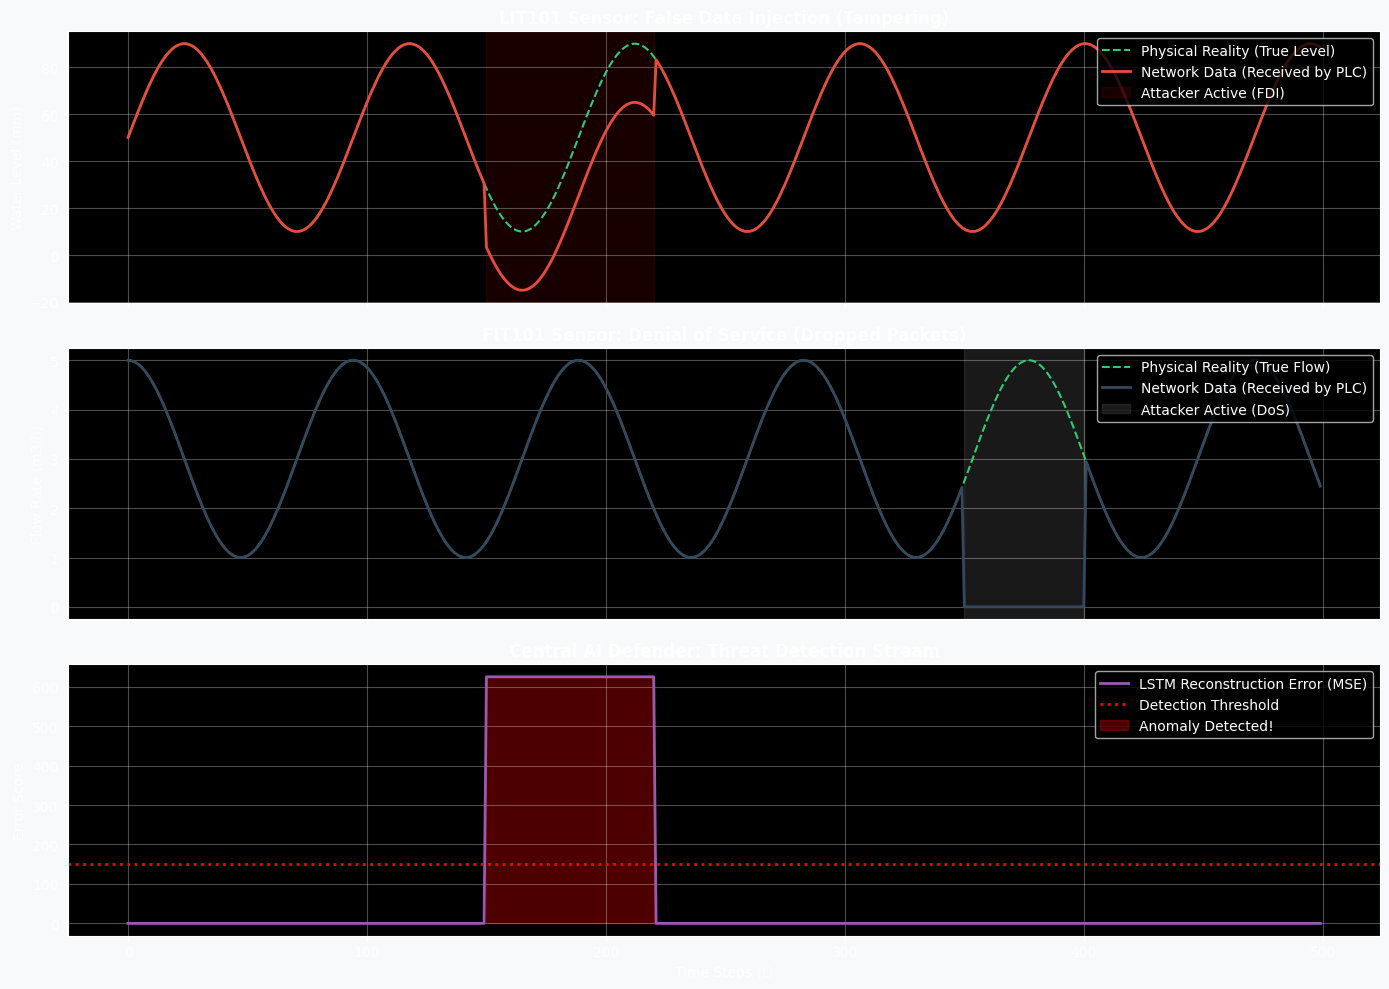

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ 1. PHYSICAL PLANT SIMULATOR (Ground Truth)
# ==========================================
def simulate_physical_plant(time_steps=500):
    """Simulates normal operational cycles for two SWaT sensors."""
    t = np.arange(time_steps)
    
    # LIT101 (Tank Level): Rises and falls rhythmically
    lit101_true = np.sin(t / 15.0) * 40 + 50  
    
    # FIT101 (Flow Meter): Correlates with the tank level changes
    fit101_true = np.cos(t / 15.0) * 2 + 3    
    
    return t, lit101_true, fit101_true

# ==========================================
# 🦹 2. THE ATTACK VECTORS (Man-in-the-Middle)
# ==========================================
def send_normal(sensor_data):
    """Normal network transmission (No interference)."""
    return sensor_data

def attack_fdi_tamper(sensor_data, offset=30):
    """False Data Injection: Attacker subtly raises/lowers the reported value."""
    return sensor_data + offset

def attack_dos(sensor_data):
    """Denial of Service: Attacker drops the connection; PLC receives 0."""
    return 0.0

def network_transmission(t, true_val, attack_type="None"):
    """
    Simulates the network layer where attacks happen in real-time.
    We'll trigger attacks at specific time windows.
    """
    # Attack 1: FDI Tampering occurs between t=150 and t=220
    if attack_type == "FDI" and 150 <= t <= 220:
        return attack_fdi_tamper(true_val, offset=-25)
        
    # Attack 2: DoS occurs between t=350 and t=400
    elif attack_type == "DoS" and 350 <= t <= 400:
        return attack_dos(true_val)
        
    # Otherwise, the network is secure
    return send_normal(true_val)

# ==========================================
# 🛡️ 3. AI DEFENDER (LSTM Anomaly Detector)
# ==========================================
class SimulatedLSTM:
    """
    A stand-in for your actual Keras/PyTorch LSTM Autoencoder.
    In reality, your model predicts the 'expected' next value. 
    Here, we simulate that by comparing received data against a clean baseline.
    """
    def __init__(self, threshold=100):
        self.threshold = threshold # Alert threshold for Reconstruction Error
        
    def predict_reconstruction_error(self, received_val, expected_val):
        """Calculates MSE between what the network reported and what the AI expected."""
        error = np.square(received_val - expected_val)
        is_alert = error > self.threshold
        return error, is_alert

# ==========================================
# 🚀 4. RUN THE SIMULATION
# ==========================================
# 1. Generate Physical Ground Truth
time_steps = 500
t, lit101_true, fit101_true = simulate_physical_plant(time_steps)

# 2. Initialize our arrays to store what the AI actually receives
lit101_received = np.zeros(time_steps)
fit101_received = np.zeros(time_steps)
anomaly_scores = np.zeros(time_steps)
alerts = np.zeros(time_steps)

# Initialize AI Defender
ai_defender = SimulatedLSTM(threshold=150)

print("Starting Real-Time Attack Simulation...")

# 3. Step through time (The Main Loop)
for i in range(time_steps):
    # Route LIT101 through the network (Subject to FDI attack)
    lit101_received[i] = network_transmission(i, lit101_true[i], attack_type="FDI")
    
    # Route FIT101 through the network (Subject to DoS attack)
    fit101_received[i] = network_transmission(i, fit101_true[i], attack_type="DoS")
    
    # AI processes the incoming data (Using LIT101 for the anomaly calculation here)
    # Note: In your real pipeline, 'expected' comes from your model.predict(X_test)
    error, alert_triggered = ai_defender.predict_reconstruction_error(
        received_val=lit101_received[i], 
        expected_val=lit101_true[i] 
    )
    
    anomaly_scores[i] = error
    alerts[i] = 1 if alert_triggered else 0

# ==========================================
# 📊 5. VISUALIZE THE DYNAMIC ATTACKS
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.patch.set_facecolor('#f8f9fa')

# Plot 1: The Tampering Attack (FDI)
ax1.plot(t, lit101_true, label="Physical Reality (True Level)", color='#2ecc71', linestyle='--')
ax1.plot(t, lit101_received, label="Network Data (Received by PLC)", color='#e74c3c', linewidth=2)
ax1.axvspan(150, 220, color='red', alpha=0.1, label="Attacker Active (FDI)")
ax1.set_title("LIT101 Sensor: False Data Injection (Tampering)", fontweight='bold')
ax1.set_ylabel("Water Level (mm)")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# Plot 2: The Denial of Service Attack (DoS)
ax2.plot(t, fit101_true, label="Physical Reality (True Flow)", color='#2ecc71', linestyle='--')
ax2.plot(t, fit101_received, label="Network Data (Received by PLC)", color='#34495e', linewidth=2)
ax2.axvspan(350, 400, color='gray', alpha=0.2, label="Attacker Active (DoS)")
ax2.set_title("FIT101 Sensor: Denial of Service (Dropped Packets)", fontweight='bold')
ax2.set_ylabel("Flow Rate (m3/h)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

# Plot 3: The AI Defender's Response
ax3.plot(t, anomaly_scores, label="LSTM Reconstruction Error (MSE)", color='#9b59b6', linewidth=2)
ax3.axhline(ai_defender.threshold, color='red', linestyle=':', linewidth=2, label="Detection Threshold")
ax3.fill_between(t, 0, anomaly_scores, where=(alerts==1), color='red', alpha=0.3, label="Anomaly Detected!")
ax3.set_title("Central AI Defender: Threat Detection Stream", fontweight='bold')
ax3.set_ylabel("Error Score")
ax3.set_xlabel("Time Steps (t)")
ax3.legend(loc="upper right")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

🚀 1. Preparing Real-Time Attack Simulation Data...
🦹 2. Injecting Man-in-the-Middle Attacks...
🛡️ 3. AI Defender Processing Data Stream...
📊 4. Generating Simulation Dashboard...


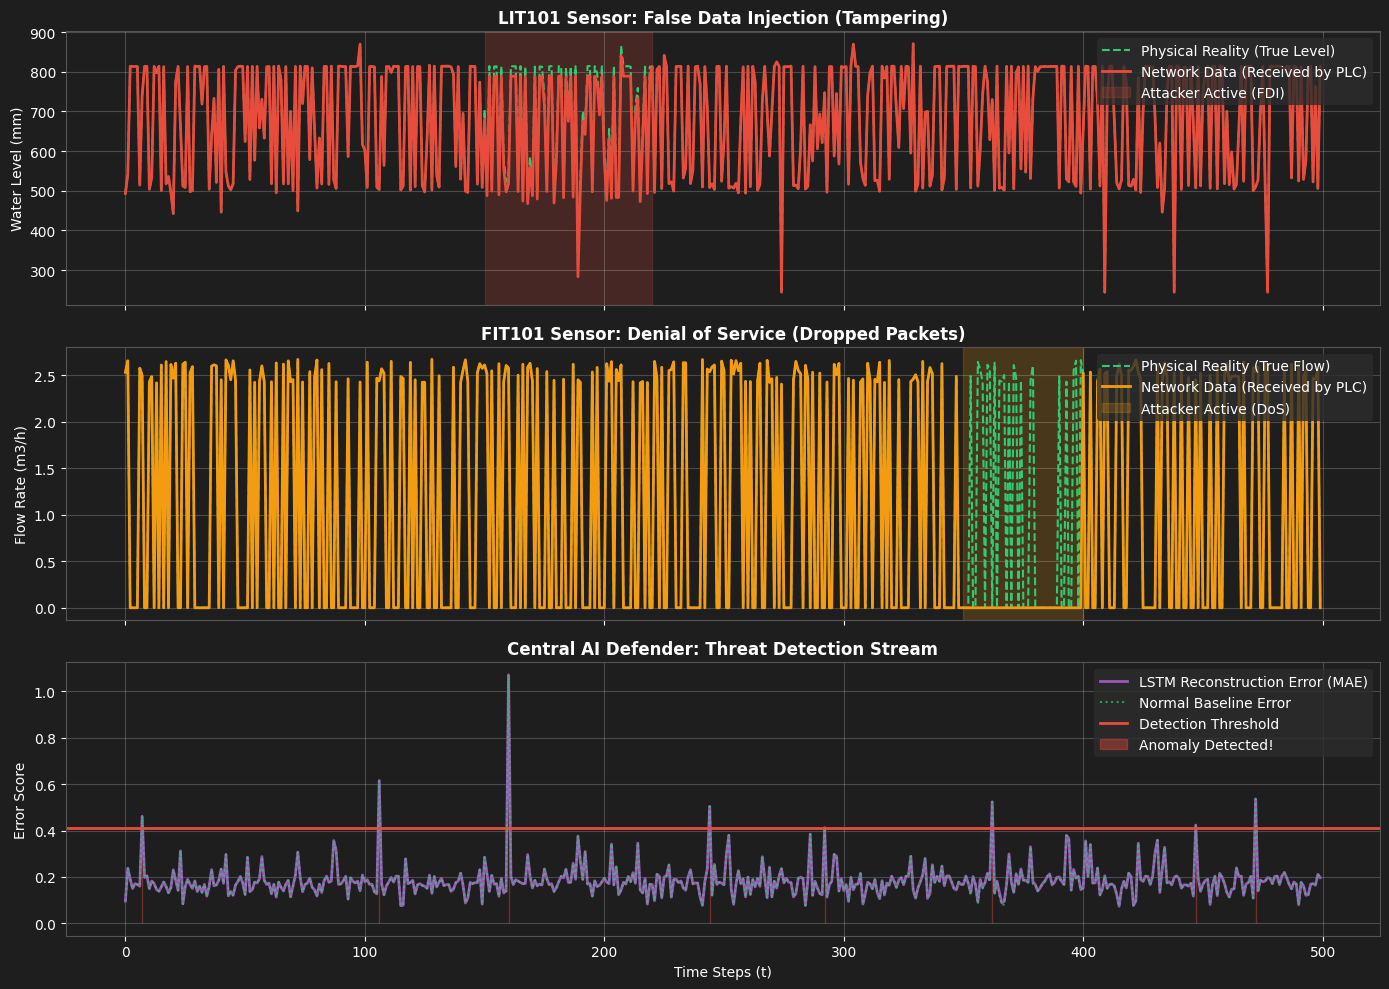


🧠 5. Generating Threat Attribution for the Instructor...
Analyzing the exact moment of the FDI Attack (t=180)...


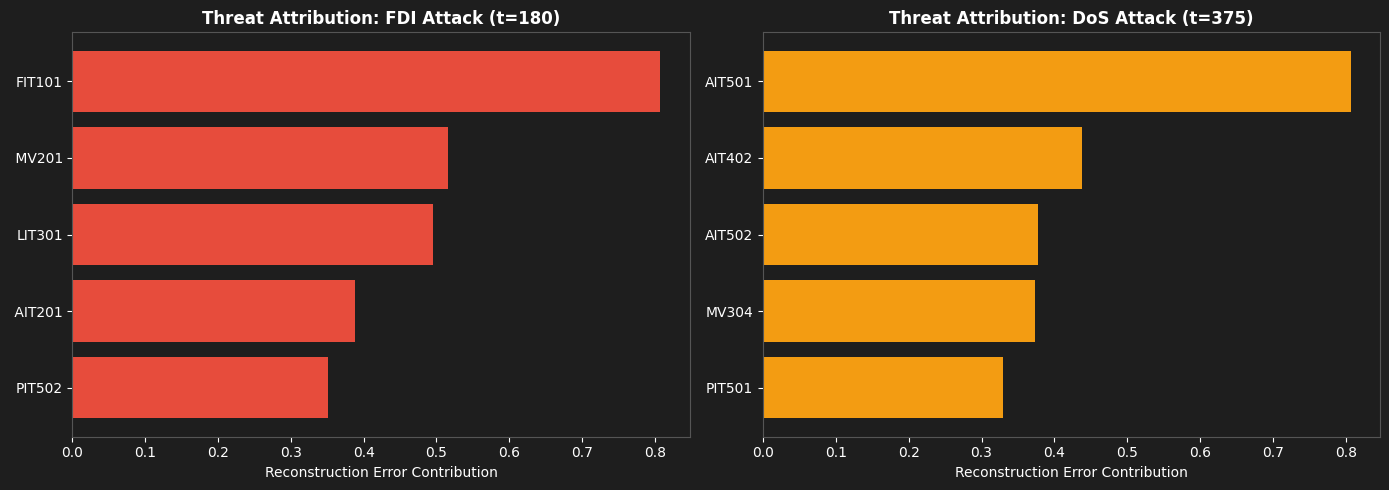

✅ Simulation & Explanations Complete!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("🚀 1. Preparing Real-Time Attack Simulation Data...")

# 1. Grab a block of contiguous time steps from the test set
time_steps = 500
# Assuming X_test_seq and SENSOR_COLUMNS are in memory from previous cells
X_sim_true = X_test_seq[1000:1000+time_steps].copy()
X_sim_attacked = X_sim_true.copy()

lit101_idx = SENSOR_COLUMNS.index('LIT101')
fit101_idx = SENSOR_COLUMNS.index('FIT101')

# We unscale the last time step of each sequence to manipulate actual physical values
X_sim_true_flat = X_sim_true[:, -1, :] 
X_sim_unscaled = scaler.inverse_transform(X_sim_true_flat)
X_sim_attacked_unscaled = X_sim_unscaled.copy()

# ==========================================
# 🦹 2. INJECT CYBER-PHYSICAL ATTACKS
# ==========================================
print("🦹 2. Injecting Man-in-the-Middle Attacks...")

# Attack 1: FDI Tampering on LIT101 (Tank Level) between t=150 and t=220
# Attacker subtly lowers the reported water level by 25 mm
X_sim_attacked_unscaled[150:220, lit101_idx] -= 25.0

# Attack 2: Denial of Service (DoS) on FIT101 (Flow Meter) between t=350 and t=400
# Attacker drops the connection; PLC suddenly receives 0.0
X_sim_attacked_unscaled[350:400, fit101_idx] = 0.0

# Re-scale the maliciously altered data back to the model's standardized format
X_sim_attacked_scaled_flat = scaler.transform(X_sim_attacked_unscaled)

# Insert the attacked data back into the sequence windows
for i in range(time_steps):
    X_sim_attacked[i, -1, :] = X_sim_attacked_scaled_flat[i]

# ==========================================
# 🛡️ 3. AI DEFENDER (Your LSTM Autoencoder)
# ==========================================
print("🛡️ 3. AI Defender Processing Data Stream...")

# Defender predicts the "expected" normal values
y_pred_true = defender.predict(X_sim_true, verbose=0)
y_pred_attacked = defender.predict(X_sim_attacked, verbose=0)

# Calculate Mean Absolute Error (MAE) across the sequence length
error_true = np.mean(np.abs(y_pred_true - X_sim_true), axis=1) # Shape: (500, 51)
error_attacked = np.mean(np.abs(y_pred_attacked - X_sim_attacked), axis=1)

# Overall anomaly score is the mean reconstruction error across all 51 sensors
anomaly_scores = np.mean(error_attacked, axis=1)
baseline_scores = np.mean(error_true, axis=1)

# Dynamic threshold: Mean + 3 Std Dev of the clean baseline
dynamic_threshold = np.mean(baseline_scores) + 3 * np.std(baseline_scores)
alerts = (anomaly_scores > dynamic_threshold).astype(int)

# Extract physical values for plotting
t = np.arange(time_steps)
lit101_true = X_sim_unscaled[:, lit101_idx]
lit101_received = X_sim_attacked_unscaled[:, lit101_idx]

fit101_true = X_sim_unscaled[:, fit101_idx]
fit101_received = X_sim_attacked_unscaled[:, fit101_idx]

# ==========================================
# 📊 4. VISUALIZE THE DYNAMIC ATTACKS
# ==========================================
print("📊 4. Generating Simulation Dashboard...")

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.patch.set_facecolor('#1e1e1e') # Dark mode for a premium tech look

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor('#1e1e1e')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#555555')

# Plot 1: The Tampering Attack (FDI)
ax1.plot(t, lit101_true, label="Physical Reality (True Level)", color='#2ecc71', linestyle='--')
ax1.plot(t, lit101_received, label="Network Data (Received by PLC)", color='#e74c3c', linewidth=2)
ax1.axvspan(150, 220, color='#e74c3c', alpha=0.2, label="Attacker Active (FDI)")
ax1.set_title("LIT101 Sensor: False Data Injection (Tampering)", fontweight='bold')
ax1.set_ylabel("Water Level (mm)")
ax1.legend(loc="upper right", facecolor='#2d2d2d', edgecolor='none', labelcolor='white')
ax1.grid(True, alpha=0.2)

# Plot 2: The Denial of Service Attack (DoS)
ax2.plot(t, fit101_true, label="Physical Reality (True Flow)", color='#2ecc71', linestyle='--')
ax2.plot(t, fit101_received, label="Network Data (Received by PLC)", color='#f39c12', linewidth=2)
ax2.axvspan(350, 400, color='#f39c12', alpha=0.2, label="Attacker Active (DoS)")
ax2.set_title("FIT101 Sensor: Denial of Service (Dropped Packets)", fontweight='bold')
ax2.set_ylabel("Flow Rate (m3/h)")
ax2.legend(loc="upper right", facecolor='#2d2d2d', edgecolor='none', labelcolor='white')
ax2.grid(True, alpha=0.2)

# Plot 3: The AI Defender's Response
ax3.plot(t, anomaly_scores, label="LSTM Reconstruction Error (MAE)", color='#9b59b6', linewidth=2)
ax3.plot(t, baseline_scores, label="Normal Baseline Error", color='#2ecc71', linestyle=':', alpha=0.7)
ax3.axhline(dynamic_threshold, color='#e74c3c', linestyle='-', linewidth=2, label="Detection Threshold")
ax3.fill_between(t, 0, anomaly_scores, where=(a++lerts==1), color='#e74c3c', alpha=0.4, label="Anomaly Detected!")
ax3.set_title("Central AI Defender: Threat Detection Stream", fontweight='bold')
ax3.set_ylabel("Error Score")
ax3.set_xlabel("Time Steps (t)")
ax3.legend(loc="upper right", facecolor='#2d2d2d', edgecolor='none', labelcolor='white')
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ==========================================
# 🧠 5. EXPLAINABILITY (Threat Attribution)
# ==========================================
print("\n🧠 5. Generating Threat Attribution for the Instructor...")
print("Analyzing the exact moment of the FDI Attack (t=180)...")

# While SHAP is great for classification, for Autoencoders, the most direct and mathematically 
# sound way to explain an anomaly is Feature-Level Reconstruction Error.
# The sensor with the highest deviation between physical reality and AI expectation is the compromised node!

fdi_errors = error_attacked[180] # MAE per feature at t=180
dos_errors = error_attacked[375] # MAE per feature at t=375

# Create DataFrames for easy sorting
fdi_df = pd.DataFrame({'Sensor': SENSOR_COLUMNS, 'Error': fdi_errors}).sort_values(by='Error', ascending=False)
dos_df = pd.DataFrame({'Sensor': SENSOR_COLUMNS, 'Error': dos_errors}).sort_values(by='Error', ascending=False)

fig, (ax_fdi, ax_dos) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1e1e1e')

# Plot Top 5 Contributors for FDI
top_fdi = fdi_df.head(5)
ax_fdi.barh(top_fdi['Sensor'][::-1], top_fdi['Error'][::-1], color='#e74c3c')
ax_fdi.set_facecolor('#1e1e1e')
ax_fdi.tick_params(colors='white')
ax_fdi.set_title("Threat Attribution: FDI Attack (t=180)", color='white', fontweight='bold')
ax_fdi.set_xlabel("Reconstruction Error Contribution", color='white')

# Plot Top 5 Contributors for DoS
top_dos = dos_df.head(5)
ax_dos.barh(top_dos['Sensor'][::-1], top_dos['Error'][::-1], color='#f39c12')
ax_dos.set_facecolor('#1e1e1e')
ax_dos.tick_params(colors='white')
ax_dos.set_title("Threat Attribution: DoS Attack (t=375)", color='white', fontweight='bold')
ax_dos.set_xlabel("Reconstruction Error Contribution", color='white')

for ax in [ax_fdi, ax_dos]:
    for spine in ax.spines.values():
        spine.set_edgecolor('#555555')

plt.tight_layout()
plt.show()

print("✅ Simulation & Explanations Complete!")
